# **EDA FASHION MNIST**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set = datasets.FashionMNIST(root='./data_fashion', train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root='./data_fashion', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 270kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.07MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.64MB/s]


In [2]:
import numpy as np

images = train_set.data.numpy()
labels = train_set.targets.numpy()

# 3. Ratakan (flatten) gambar 2D (28x28) menjadi array 1D (784 piksel)
# Menggunakan -1 otomatis mendeteksi jumlah total baris (60,000)
X_flattened = images.reshape(images.shape[0], -1)

# 4. Masukkan ke dalam Pandas DataFrame
df = pd.DataFrame(X_flattened)
df.info()

# 5. Tambahkan kolom label ke dalam DataFrame agar data lengkap
df['label'] = labels

# Intip hasil data
print(f"Ukuran DataFrame: {df.shape}")
print(df.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 784 entries, 0 to 783
dtypes: uint8(784)
memory usage: 44.9 MB
Ukuran DataFrame: (60000, 785)
   0  1  2  3  4  5  6  7   8   9  ...  775  776  777  778  779  780  781  \
0  0  0  0  0  0  0  0  0   0   0  ...    0    0    0    0    0    0    0   
1  0  0  0  0  0  1  0  0   0   0  ...  114  130   76    0    0    0    0   
2  0  0  0  0  0  0  0  0   0  22  ...    0    1    0    0    0    0    0   
3  0  0  0  0  0  0  0  0  33  96  ...    0    0    0    0    0    0    0   
4  0  0  0  0  0  0  0  0   0   0  ...    0    0    0    0    0    0    0   
5  0  0  0  0  1  0  0  0   0  22  ...    0    0    0  133  167   73    0   
6  0  0  0  0  0  0  0  0   0   0  ...    0    0    0    0    0    0    0   
7  0  0  0  0  0  1  1  0   0   0  ...    0    3    0   82  237  231   70   
8  0  0  0  0  0  0  0  0   0   0  ...    0    0    0    0    0    0    0   
9  0  0  0  0  0  0  0  0   0   0  ...    0    0   

In [3]:
# Menghitung sparsity atau angka 0 di semua kolom dan baris
zero_number = (df == 0).sum().sum()
print(f"Zero number: {zero_number}")

sparsity = zero_number / (60000 * 785)
# Menampilkan sparsity dalam bentuk persen
print(f"Sparsity: {sparsity * 100:.2f}%")

Zero number: 23622498
Sparsity: 50.15%


In [4]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,0.000800,0.005783,0.030083,0.103800,0.249683,0.414717,0.821667,2.224733,5.698667,14.434650,...,23.208633,16.576250,17.831967,22.918850,17.916900,8.485717,2.706333,0.819000,0.070883,4.500000
std,0.092554,0.249033,0.767868,2.512017,4.331376,5.827394,8.309935,14.201820,23.835980,38.204702,...,48.881430,42.044318,43.911297,51.928401,45.173634,29.448614,17.258682,9.133252,2.075829,2.872305
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.500000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000
max,16.000000,36.000000,119.000000,164.000000,224.000000,230.000000,221.000000,221.000000,254.000000,255.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,170.000000,9.000000


## Statistik Dasar Dataset

In [5]:
print(f"jumlah training sample: {len(train_set)}")
print(f"jumlah test sample: {len(test_set)}")
print(f"dimensi gambar: {train_set[0][0].shape}")
print(f"jumlah kelas: {len(train_set.classes)}")

jumlah training sample: 60000
jumlah test sample: 10000
dimensi gambar: torch.Size([1, 28, 28])
jumlah kelas: 10


## Distribusi Label Dataset

         Kelas  Jumlah
0  T-shirt/top    6000
1      Trouser    6000
2     Pullover    6000
3        Dress    6000
4         Coat    6000
5       Sandal    6000
6        Shirt    6000
7      Sneaker    6000
8          Bag    6000
9   Ankle boot    6000


/tmp/ipykernel_9093/1693015157.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=class_counts.values, palette='viridis')


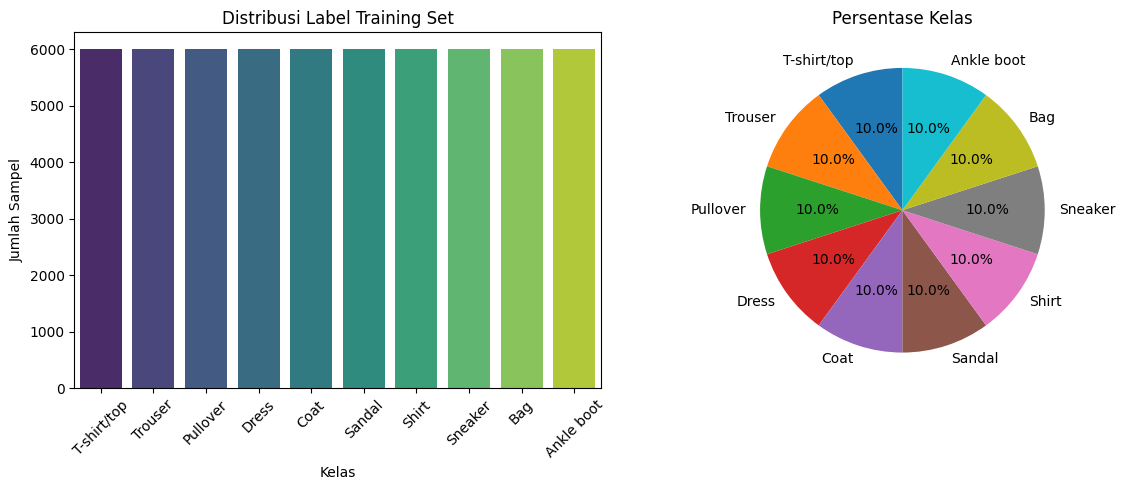

In [6]:
# Hitung frekuensi per kelas
class_counts = df['label'].value_counts().sort_index()
class_names = train_set.classes

# Tampilkan dalam DataFrame
label_dist = pd.DataFrame({
    'Kelas': class_names,
    'Jumlah': class_counts.values
})
print(label_dist)

# Visualisasi
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
sns.barplot(x=class_names, y=class_counts.values, palette='viridis')
plt.title('Distribusi Label Training Set')
plt.ylabel('Jumlah Sampel')
plt.xlabel('Kelas')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(class_counts.values, labels=class_names, autopct='%1.1f%%', startangle=90)
plt.title('Persentase Kelas')

plt.tight_layout()
plt.show()

In [7]:
print(f"Rata-rata sampel per kelas: {class_counts.mean():.0f}")
print(f"Std dev sampel per kelas: {class_counts.std():.2f}")
print(f"Dataset seimbang? {'Ya' if class_counts.std() < 100 else 'Tidak sempurna'}")

Rata-rata sampel per kelas: 6000
Std dev sampel per kelas: 0.00
Dataset seimbang? Ya


## Visualiasi Gambar Dataset

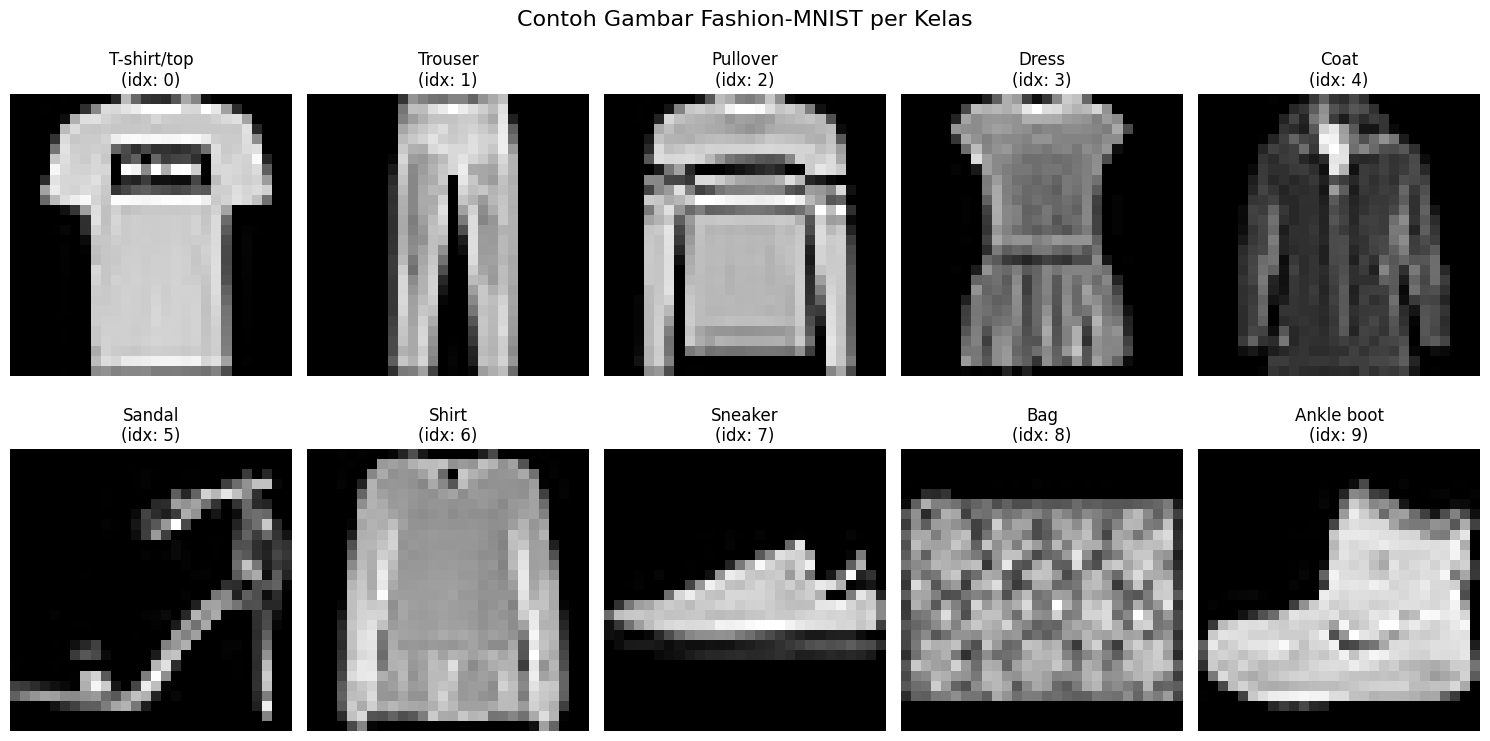

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
fig.suptitle('Contoh Gambar Fashion-MNIST per Kelas', fontsize=16)

for idx, class_name in enumerate(class_names):
    # Ambil satu gambar pertama dari setiap kelas
    class_indices = np.where(labels == idx)[0]
    sample_idx = class_indices[0]

    row = idx // 5
    col = idx % 5

    # Tampilkan gambar
    axes[row, col].imshow(images[sample_idx], cmap='gray')
    axes[row, col].set_title(f'{class_name}\n(idx: {idx})')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## Brightness Distribution

      Kelas      Mean       Std  Min  Max
T-shirt/top 83.029980 89.438480    0  255
    Trouser 56.840855 87.600263    0  255
   Pullover 96.058763 91.463466    0  255
      Dress 66.018909 90.326001    0  255
       Coat 98.258006 95.959524    0  255
     Sandal 34.867547 67.092563    0  255
      Shirt 84.605120 86.516051    0  255
    Sneaker 42.762072 75.170573    0  255
        Bag 90.157153 93.144150    0  255
 Ankle boot 76.805118 94.485883    0  255


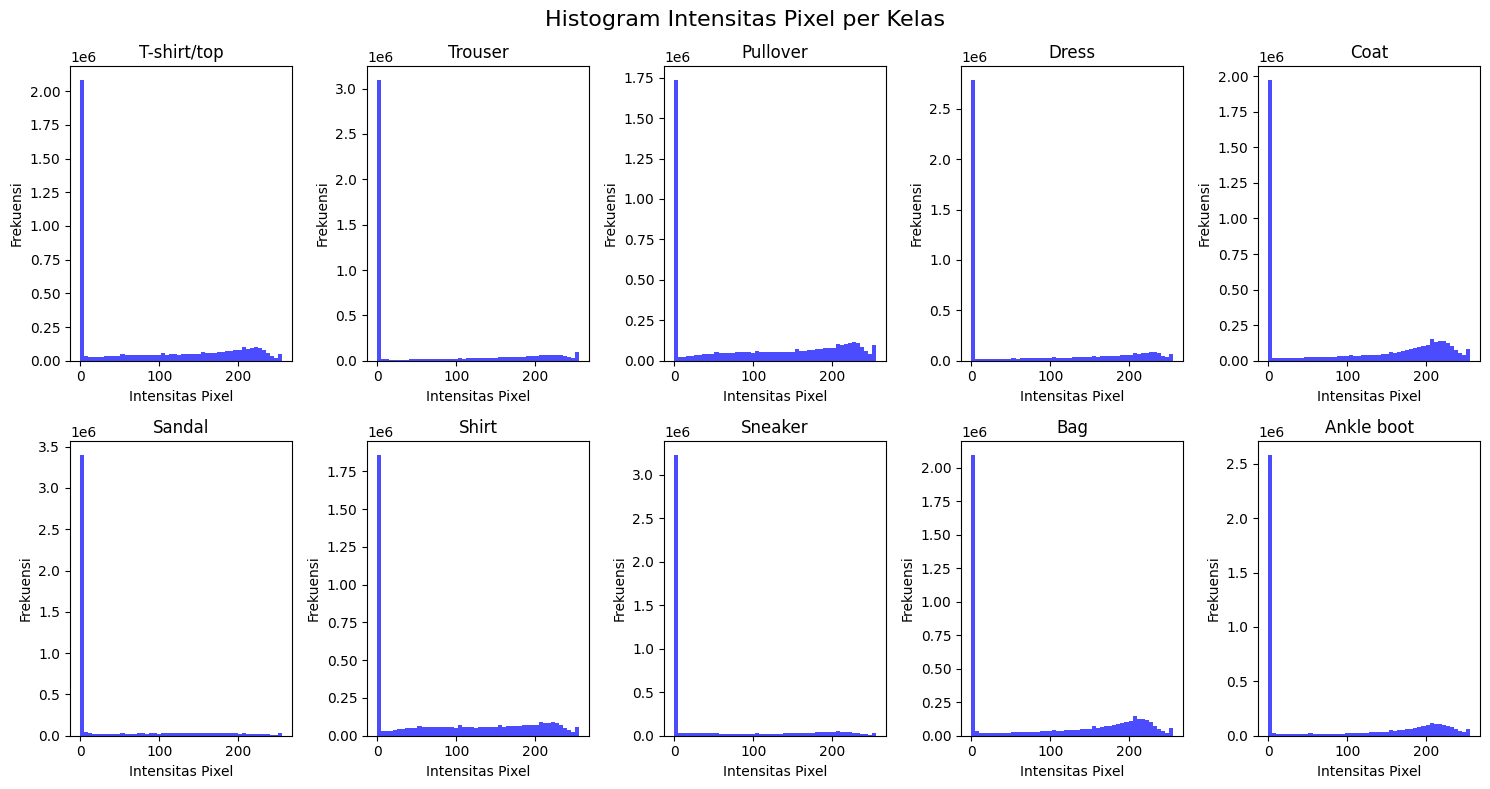

In [9]:
# Statistik ringkasan per kelas
pixel_stats = []
for i in range(10):
    class_images = images[labels == i]
    pixel_stats.append({
        'Kelas': class_names[i],
        'Mean': class_images.mean(),
        'Std': class_images.std(),
        'Min': class_images.min(),
        'Max': class_images.max()
    })

pixel_df = pd.DataFrame(pixel_stats)
print(pixel_df.to_string(index=False))

# Visualisasi distribusi pixel per kelas
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
fig.suptitle('Histogram Intensitas Pixel per Kelas', fontsize=16)

for idx, class_name in enumerate(class_names):
    row = idx // 5
    col = idx % 5

    class_images = images[labels == idx]
    axes[row, col].hist(class_images.flatten(), bins=50, alpha=0.7, color='blue')
    axes[row, col].set_title(f'{class_name}')
    axes[row, col].set_xlabel('Intensitas Pixel')
    axes[row, col].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

## Analisis Mean Intensitas Pixel

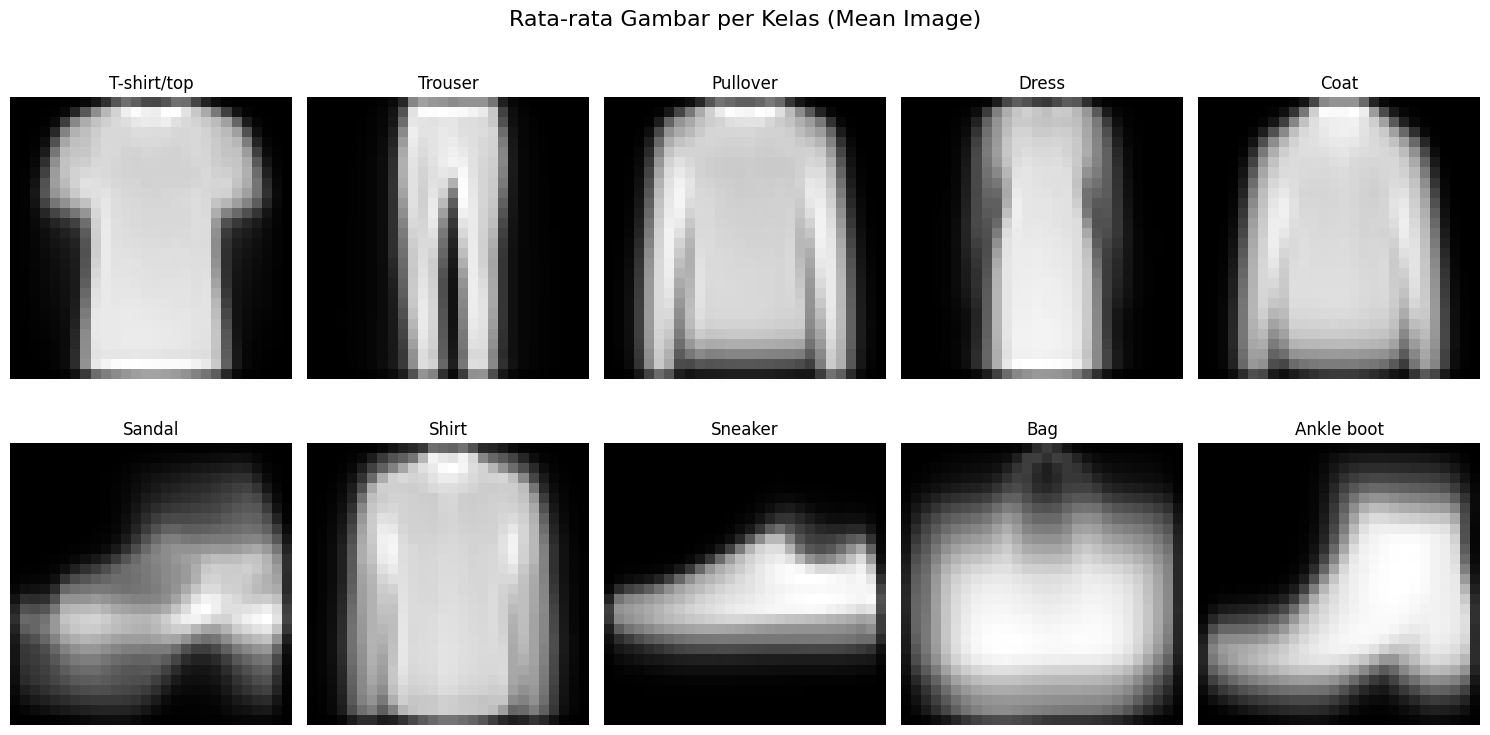


ANALISIS VARIANCE PIXEL
Variance global semua gambar: 0.1246
T-shirt/top    : 0.1230
Trouser        : 0.1180
Pullover       : 0.1287
Dress          : 0.1255
Coat           : 0.1416
Sandal         : 0.0692
Shirt          : 0.1151
Sneaker        : 0.0869
Bag            : 0.1334
Ankle boot     : 0.1373


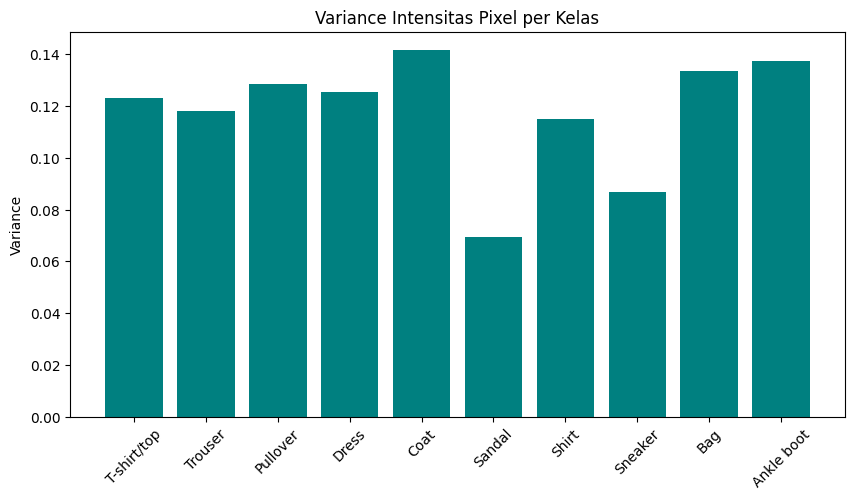

In [12]:
# Mean image per kelas
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
fig.suptitle('Rata-rata Gambar per Kelas (Mean Image)', fontsize=16)

for idx, class_name in enumerate(class_names):
    row = idx // 5
    col = idx % 5

    class_images = images[labels == idx]
    mean_img = class_images.mean(axis=0)

    axes[row, col].imshow(mean_img, cmap='gray')
    axes[row, col].set_title(f'{class_name}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Analisis variance per pixel (penting untuk normalisasi)
print("\n"+"ANALISIS VARIANCE PIXEL")
print("="*50)

# Hitung variance global
global_variance = np.var(images / 255.0)
print(f"Variance global semua gambar: {global_variance:.4f}")

# Variance per kelas
variance_per_class = []
for i in range(10):
    class_images = images[labels == i] / 255.0
    var = np.var(class_images)
    variance_per_class.append(var)
    print(f"{class_names[i]:15s}: {var:.4f}")

# Visualisasi variance per kelas
plt.figure(figsize=(10, 5))
plt.bar(class_names, variance_per_class, color='teal')
plt.title('Variance Intensitas Pixel per Kelas')
plt.ylabel('Variance')
plt.xticks(rotation=45)
plt.show()

# **DEFINISI FUNGSI MODULAR**

---



## Setup Fashion MNIST

In [5]:
def setup_fashion_mnist_environment(model_name, force_remount=True):
    """
    Menangani mounting drive, setup path, dan inisialisasi DataLoaders.
    """
    from google.colab import drive
    import os

    # 1. Mount Drive
    drive.mount('/content/drive', force_remount=True)

    # 2. Setup Paths
    model_dir = '/content/drive/MyDrive/model_modular'
    os.makedirs(model_dir, exist_ok=True)
    path = os.path.join(model_dir, model_name)

    return path, train_loader, test_loader

print("✅ Helper function setup_fashion_mnist_environment siap digunakan.")

✅ Helper function setup_fashion_mnist_environment siap digunakan.


## Load or Training Model & Eval Model

In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

def evaluate_accuracy(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def load_and_prepare_model(model_class, model_path, train_loader, test_loader, device, num_epochs=10, lr=0.001):
    model = model_class().to(device)
    history = {'loss': [], 'accuracy': []}

    if os.path.exists(model_path):
        print(f"✅ Loading existing model from {model_path}...")
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        history = checkpoint.get('history', history)
        print(f"✅ Model loaded. Previous accuracy: {history['accuracy'][-1]:.2f}%" if history['accuracy'] else "✅ Model loaded.")
    else:
        print(f"❌ No model found at {model_path}. Starting training...")
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        for epoch in range(num_epochs):
            model.train()
            running_loss = 0.0
            for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()

            acc = evaluate_accuracy(model, test_loader, device)
            avg_loss = running_loss / len(train_loader)
            history['loss'].append(avg_loss)
            history['accuracy'].append(acc)
            print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {acc:.2f}%")

        print(f"💾 Saving model to {model_path}...")
        torch.save({'model_state_dict': model.state_dict(), 'history': history}, model_path)
        print("✅ Training complete and model saved.")

    return model, history

print("✅ Unified Model Manager & Trainer defined!")

✅ Unified Model Manager & Trainer defined!


## Fungsi Kuantisasi Modular

Standard & Fine-Grained Quantization Ternary


In [7]:
import torch
import torch.nn as nn
import copy
import numpy as np
import os
import json

def standard_ternary_quantize(weight_tensor, asymmetric=False):
    original_shape = weight_tensor.shape
    flat_weights = weight_tensor.flatten()

    if not asymmetric:
        abs_weights = torch.abs(flat_weights)
        if abs_weights.max().item() == 0:
            return torch.zeros_like(weight_tensor), 0.0
        delta = 0.7 * torch.mean(abs_weights)
        mask = abs_weights > delta
        if mask.sum() == 0:
            return torch.zeros_like(weight_tensor), 0.0
        alpha = abs_weights[mask].sum() / mask.sum().float()
        ternary_flat = torch.zeros_like(flat_weights)
        ternary_flat[flat_weights > delta] = alpha
        ternary_flat[flat_weights < -delta] = -alpha
        return ternary_flat.reshape(original_shape), alpha.item()
    else:
        pos_mask = flat_weights > 0
        neg_mask = flat_weights < 0
        a_pos, a_neg = 0.0, 0.0
        d_pos, d_neg = 0.0, 0.0
        if pos_mask.any():
            pos_vals = flat_weights[pos_mask]
            d_pos = 0.7 * torch.mean(pos_vals)
            m_pos = pos_vals > d_pos
            if m_pos.any(): a_pos = torch.mean(pos_vals[m_pos])
        if neg_mask.any():
            neg_vals = flat_weights[neg_mask]
            d_neg = 0.7 * torch.mean(torch.abs(neg_vals))
            m_neg = torch.abs(neg_vals) > d_neg
            if m_neg.any(): a_neg = torch.mean(neg_vals[m_neg])
        ternary_flat = torch.zeros_like(flat_weights)
        ternary_flat[flat_weights > d_pos] = a_pos
        ternary_flat[flat_weights < -d_neg] = a_neg
        avg_alpha = (abs(a_pos) + abs(a_neg)) / 2.0
        return ternary_flat.reshape(original_shape), avg_alpha.item() if torch.is_tensor(avg_alpha) else avg_alpha

def apply_standard_ternary_to_model(model, asymmetric=False, verbose=False, save_path=None):
    if save_path and os.path.exists(save_path):
        print(f"✅ Loading existing Standard Ternary model from {save_path}...")
        return load_ternary_safetensors(save_path, model), None

    model_q = copy.deepcopy(model)
    layer_alphas = []
    for name, module in model_q.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            ternary_weight, alpha = standard_ternary_quantize(module.weight.data, asymmetric=asymmetric)
            module.weight.data = ternary_weight
            layer_alphas.append(alpha)
            if verbose: print(f"  ✓ {name}: quantized (Asym={asymmetric}) with alpha={alpha:.4f}")

    if save_path:
        save_ternary_safetensors(model_q, alphas=layer_alphas, path=save_path)
    return model_q, layer_alphas

def ternary_quantize_group(weight_tensor, group_size=4, asymmetric=False):
    original_shape = weight_tensor.shape
    flat_weights = weight_tensor.flatten()
    n = flat_weights.numel()
    ternary_flat = torch.zeros_like(flat_weights)
    alphas = []
    for i in range(0, n, group_size):
        group = flat_weights[i:min(i+group_size, n)]
        if len(group) == 0: continue
        if not asymmetric:
            abs_group = torch.abs(group)
            if abs_group.max().item() == 0:
                alphas.append(0.0)
                continue
            thresholds = torch.linspace(abs_group.min().item(), abs_group.max().item(), steps=20)
            best_delta, best_score = 0, -float('inf')
            for delta in thresholds:
                mask = abs_group > delta
                if mask.sum() == 0: continue
                score = (abs_group[mask].sum() ** 2) / mask.sum().float()
                if score > best_score: best_score, best_delta = score, delta
            mask = abs_group > best_delta
            if mask.sum() == 0:
                alphas.append(0.0)
                continue
            alpha = abs_group[mask].sum() / mask.sum().float()
            alphas.append(alpha.item())
            ternary_group = torch.zeros_like(group)
            ternary_group[group > best_delta] = alpha
            ternary_group[group < -best_delta] = -alpha
        else:
            pos_mask = group > 0
            neg_mask = group < 0
            a_pos, a_neg = 0.0, 0.0
            d_pos, d_neg = 0.0, 0.0
            if pos_mask.any():
                pos_vals = group[pos_mask]
                d_pos = 0.7 * torch.mean(pos_vals)
                m_pos = pos_vals > d_pos
                if m_pos.any(): a_pos = torch.mean(pos_vals[m_pos])
            if neg_mask.any():
                neg_vals = group[neg_mask]
                d_neg = 0.7 * torch.mean(torch.abs(neg_vals))
                m_neg = torch.abs(neg_vals) > d_neg
                if m_neg.any(): a_neg = torch.mean(neg_vals[m_neg])
            ternary_group = torch.zeros_like(group)
            ternary_group[group > d_pos] = a_pos
            ternary_group[group < -d_neg] = a_neg
            alphas.append((abs(a_pos) + abs(a_neg)).item() / 2.0 if torch.is_tensor(a_pos) else (abs(a_pos) + abs(a_neg)) / 2.0)
        ternary_flat[i:min(i+group_size, n)] = ternary_group
    return ternary_flat.reshape(original_shape), alphas

def apply_fgq_to_model(model, group_size=4, asymmetric=False, verbose=False, save_path=None):
    if isinstance(group_size, (list, set, tuple)):
        results = {}
        for gs in sorted(list(group_size)):
            sub_save_path = save_path.replace('.safetensors', f'_gs{gs}.safetensors') if save_path else None
            if sub_save_path and os.path.exists(sub_save_path):
                if verbose: print(f"✅ Loading existing FGQ model (GS={gs}) from {sub_save_path}...")
                m_q = load_ternary_safetensors(sub_save_path, model)
                results[gs] = (m_q, None)
            else:
                if verbose: print(f"\n--- Processing Group Size: {gs} (Asymmetric={asymmetric}) ---")
                m_q, a_m = apply_fgq_to_model(model, gs, asymmetric, verbose, sub_save_path)
                results[gs] = (m_q, a_m)
        return results

    if save_path and os.path.exists(save_path):
        print(f"✅ Loading existing FGQ model (GS={group_size}) from {save_path}...")
        return load_ternary_safetensors(save_path, model), None

    model_q = copy.deepcopy(model)
    all_alpha_means = []
    for name, module in model_q.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            ternary_weight, alphas = ternary_quantize_group(module.weight.data, group_size, asymmetric)
            module.weight.data = ternary_weight
            m_alpha = np.mean(alphas) if alphas else 0
            all_alpha_means.append(m_alpha)
            if verbose: print(f"  ✓ {name}: FGQ N={group_size}, Asym={asymmetric}, mean_alpha={m_alpha:.4f}")

    if save_path:
        save_ternary_safetensors(model_q, group_size=group_size, path=save_path)
    return model_q, all_alpha_means

def find_best_fgq_model(fgq_results, test_loader, device, save_log_path=None):
    best_acc = -1.0
    best_gs = None
    best_model = None
    accuracy_log = {}

    print("\n--- Evaluating All Group Sizes ---")
    for gs, (model_q, _) in fgq_results.items():
        acc = evaluate_accuracy(model_q, test_loader, device)
        accuracy_log[int(gs)] = float(acc)
        print(f"Group Size {gs}: Accuracy = {acc:.2f}%")
        if acc > best_acc:
            best_acc = acc
            best_gs = gs
            best_model = model_q

    print(f"\n✅ Best Result: Group Size {best_gs} with Accuracy {best_acc:.2f}%")

    if save_log_path:
        with open(save_log_path, 'w') as f:
            json.dump({"model_info": "FGQ Results", "accuracies": accuracy_log, "best_gs": int(best_gs)}, f, indent=4)
        print(f"💾 Accuracy log saved to: {save_log_path}")

    return best_gs, best_model, best_acc

## Definisi Model

### LeNet-5

In [8]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Redefine Model Class
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = nn.functional.avg_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = nn.functional.avg_pool2d(x, 2)
        x = x.view(-1, 16 * 5 * 5)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# 2. Re-initialize DataLoader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
test_dataset = datasets.FashionMNIST(root='./data_fashion', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# 3. Instantiate model and define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LeNet5().to(device)

print("✅ Setup for verification complete: Model and Test Loader are ready.")

✅ Setup for verification complete: Model and Test Loader are ready.


### ResNet-18

In [9]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Redefine Model Class for ResNet18
class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()
        # Load a pre-trained ResNet18 model
        self.model = models.resnet18(weights=None) # weights=None to avoid downloading ImageNet weights for now

        # Modify the first convolution layer for single-channel input (Fashion MNIST images are grayscale)
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Modify the final fully connected layer to match the number of classes (Fashion MNIST has 10 classes)
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.model(x)

# Instantiate model and define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNet18().to(device)

print("✅ ResNet18 model defined and ready.")

✅ ResNet18 model defined and ready.


## Fungsi Penyimpanan Kuantisasi

In [10]:
import torch
import os
import copy
import json
from safetensors.torch import save_file, load_file

def pack_2bit(mask):
    """Pack 4 ternary values into 1 byte (using 0, 1, 2 mapping)"""
    flat = mask.flatten().to(torch.uint8)
    n = flat.numel()
    pad = (4 - (n % 4)) % 4
    if pad > 0:
        flat = torch.cat([flat, torch.zeros(pad, dtype=torch.uint8)])

    # Reshape to (N/4, 4) and pack
    grouped = flat.view(-1, 4)
    packed = (grouped[:, 0] & 3) | ((grouped[:, 1] & 3) << 2) | ((grouped[:, 2] & 3) << 4) | ((grouped[:, 3] & 3) << 6)
    return packed, mask.shape

def unpack_2bit(packed, shape, numel):
    """Unpack uint8 back to ternary mask"""
    unpacked = torch.zeros(packed.numel(), 4, dtype=torch.uint8, device=packed.device)
    unpacked[:, 0] = packed & 3
    unpacked[:, 1] = (packed >> 2) & 3
    unpacked[:, 2] = (packed >> 4) & 3
    unpacked[:, 3] = (packed >> 6) & 3

    mask = unpacked.flatten()[:numel].reshape(shape)
    return mask.to(torch.int8)

def save_ternary_safetensors(model, alphas=None, group_size=None, path='model.safetensors'):
    tensors = {}
    meta_list = []

    for name, module in model.named_modules():
        # --- BatchNorm ---
        if isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
            tensors[f"{name}.weight"] = module.weight.data.clone()
            tensors[f"{name}.bias"] = module.bias.data.clone()
            tensors[f"{name}.running_mean"] = module.running_mean.clone()
            tensors[f"{name}.running_var"] = module.running_var.clone()
            meta_list.append({"n": name, "type": "bn"})
            continue

        # --- Conv2d / Linear ---
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            w = module.weight.data
            # Buat mask ternary: 0=negatif, 1=no1, 2=positif
            m = torch.zeros_like(w, dtype=torch.int8)
            m[w < 0] = 0
            m[w == 0] = 1
            m[w > 0] = 2

            packed, original_shape = pack_2bit(m)
            tensors[f"{name}.p"] = packed

            info = {
                "n": name,
                "type": "linear",
                "s": list(original_shape),
                "num": w.numel(),
                "has_bias": module.bias is not None
            }

            if module.bias is not None:
                tensors[f"{name}.bias"] = module.bias.data.clone()

            # --- Penanganan Alpha ---
            if alphas is not None:
                # Standard Ternary: satu alpha per layer
                linear_count = len([m for m in meta_list if m.get("type") == "linear"])
                info["a"] = float(alphas[linear_count]) if linear_count < len(alphas) else 1.0
            else:
                # FGQ Asimetris: simpan alpha per group dalam satu tensor (N, 2)
                gs = group_size or 4
                info["gs"] = gs
                flat_w = w.flatten()
                alpha_pairs = []
                for i in range(0, flat_w.numel(), gs):
                    g = flat_w[i:i+gs]
                    pos_vals = g[g > 0]
                    neg_vals = g[g < 0]
                    a_pos = pos_vals.mean().item() if pos_vals.numel() > 0 else 0.0
                    a_neg = neg_vals.mean().item() if neg_vals.numel() > 0 else 0.0
                    alpha_pairs.append([a_pos, a_neg])
                tensors[f"{name}.alpha"] = torch.tensor(alpha_pairs, dtype=torch.float32)  # shape (num_groups, 2)

            meta_list.append(info)

    save_file(tensors, path, metadata={"config": json.dumps(meta_list)})
    print(f"✅ Saved: {path}")

def load_ternary_safetensors(path, template_model):
    from safetensors import safe_open

    tensors = load_file(path)
    with safe_open(path, framework="pt") as f:
        meta_list = json.loads(f.metadata()["config"])

    # Buat salinan model template
    model = copy.deepcopy(template_model)
    state_dict = model.state_dict()

    for info in meta_list:
        name = info["n"]

        # --- BatchNorm ---
        if info.get("type") == "bn":
            state_dict[f"{name}.weight"] = tensors[f"{name}.weight"]
            state_dict[f"{name}.bias"] = tensors[f"{name}.bias"]
            state_dict[f"{name}.running_mean"] = tensors[f"{name}.running_mean"]
            state_dict[f"{name}.running_var"] = tensors[f"{name}.running_var"]
            continue

        # --- Conv2d / Linear ---
        packed = tensors[f"{name}.p"]
        mask = unpack_2bit(packed, info["s"], info["num"])

        # Rekonstruksi bobot dasar (-1, 0, +1)
        w_rec = torch.zeros(info["num"], dtype=torch.float32)
        mask_flat = mask.flatten()
        w_rec[mask_flat == 0] = -1.0
        w_rec[mask_flat == 1] = 0.0
        w_rec[mask_flat == 2] = 1.0

        # --- Terapkan Alpha ---
        if "a" in info:
            # Standard Ternary
            w_rec *= info["a"]
        elif "gs" in info:
            # FGQ Asimetris: alpha per group (tensor (num_groups, 2))
            gs = info["gs"]
            alpha = tensors[f"{name}.alpha"]  # shape (num_groups, 2)
            for i in range(alpha.shape[0]):
                start = i * gs
                end = min(start + gs, info["num"])
                segment = w_rec[start:end]
                # Terapkan alpha positif (kolom 0) ke nilai > 0
                segment[segment > 0] = alpha[i, 0]
                # Terapkan alpha negatif (kolom 1) ke nilai < 0
                segment[segment < 0] = alpha[i, 1]
                w_rec[start:end] = segment

        # Update weight
        state_dict[f"{name}.weight"] = w_rec.reshape(info["s"])

        # Update bias jika ada
        if info.get("has_bias", False) and f"{name}.bias" in tensors:
            state_dict[f"{name}.bias"] = tensors[f"{name}.bias"]

    model.load_state_dict(state_dict)
    return model

## Generate Input Batch

In [11]:
import torch
import numpy as np
from torchvision import datasets, transforms

# Load Fashion-MNIST test set
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Ambil 100 gambar pertama
batch_size = 100
inputs = []
for i in range(batch_size):
    img, label = test_dataset[i]
    input_flat = img.numpy().flatten().astype(np.float32)
    inputs.append(input_flat)

# Simpan sebagai satu file .bin (100 x 784 = 78,400 float32)
all_inputs = np.array(inputs).flatten()
all_inputs.tofile('batch_input.bin')
print(f"✅ Batch input saved: {all_inputs.shape}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 270kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.6MB/s]

✅ Batch input saved: (78400,)


# **PENGUJIAN TRAINING & KUANTISASI**

---



## Model Setup

#### ResNet-18

In [12]:
# 1. Siapkan environment (Drive, Path, Data)
model_path_resnet, train_loader_resnet, test_loader_resnet = setup_fashion_mnist_environment('resnet18_fashion_baseline.pth')

# 2. Panggil manager model
model_fp32_resnet, history_resnet = load_and_prepare_model(
    ResNet18,
    model_path_resnet,
    train_loader_resnet,
    test_loader_resnet,
    device,
    num_epochs=5
)

print(f"\nProses selesai. Akurasi Baseline: {history_resnet['accuracy'][-1]:.2f}%")

Mounted at /content/drive
✅ Loading existing model from /content/drive/MyDrive/model_modular/resnet18_fashion_baseline.pth...
✅ Model loaded. Previous accuracy: 89.91%

Proses selesai. Akurasi Baseline: 89.91%


#### LeNet-5

In [13]:
# 1. Siapkan environment (Drive, Path, Data)
model_path_lenet, train_loader_lenet, test_loader_lenet = setup_fashion_mnist_environment('lenet5_fashion_baseline.pth')

# 2. Panggil manager model
model_fp32_lenet, history_lenet = load_and_prepare_model(
    LeNet5,
    model_path_lenet,
    train_loader_lenet,
    test_loader_lenet,
    device,
    num_epochs=5
)

print(f"\nProses selesai. Akurasi Baseline: {history_lenet['accuracy'][-1]:.2f}%")

Mounted at /content/drive
✅ Loading existing model from /content/drive/MyDrive/model_modular/lenet5_fashion_baseline.pth...
✅ Model loaded. Previous accuracy: 86.17%

Proses selesai. Akurasi Baseline: 86.17%


## Kuantisasi Model

### *Standard Ternary Quantization*

#### ResNet-18

In [20]:
model_ternary_resnet, alphas_resnet = apply_standard_ternary_to_model(model_fp32_resnet, asymmetric=True, verbose=True,save_path="/content/drive/MyDrive/model_modular/safetensors_models/resnet18_standard_fashion.safetensors")
acc_ternary_resnet = evaluate_accuracy(model_ternary_resnet, test_loader, device)

print(f"Baseline: {history_resnet['accuracy'][-1]:.2f}%")
print(f"Ternary: {acc_ternary_resnet:.2f}%")

✅ Loading existing Standard Ternary model from /content/drive/MyDrive/model_modular/safetensors_models/resnet18_standard_fashion.safetensors...
Baseline: 89.91%
Ternary: 24.55%


harusnya 24.74% tapi karena mengikuti fungsi load safetensors jadinya mengikuti hasil akurasi load model, agak mismatch sedikit

#### LeNet-5

In [21]:
model_ternary_lenet, alphas_lenet = apply_standard_ternary_to_model(model_fp32_lenet, asymmetric=True, verbose=True,save_path="/content/drive/MyDrive/model_modular/safetensors_models/lenet5_standard_fashion.safetensors")
acc_ternary_lenet = evaluate_accuracy(model_ternary_lenet, test_loader, device)

print(f"Baseline: {history_lenet['accuracy'][-1]:.2f}%")
print(f"Ternary: {acc_ternary_lenet:.2f}%")

✅ Loading existing Standard Ternary model from /content/drive/MyDrive/model_modular/safetensors_models/lenet5_standard_fashion.safetensors...
Baseline: 86.17%
Ternary: 73.73%


### *Fine-Grained Ternary Quantization*

#### ResNet-18

In [19]:
fgq_results_resnet = apply_fgq_to_model(model_fp32_resnet, group_size={4, 8, 16}, asymmetric=True, verbose=True, save_path="/content/drive/MyDrive/model_modular/safetensors_models/resnet18_fgq_fashion.safetensors")

best_gs_resnet, best_model_fgq_resnet, best_acc_resnet = find_best_fgq_model(fgq_results_resnet, test_loader_resnet, device)

print(f"\nBaseline Accuracy: {history_resnet['accuracy'][-1]:.2f}%")
print(f"Akurasi Terbaik ditemukan pada Group Size {best_gs_resnet}: {best_acc_resnet:.2f}%")


--- Processing Group Size: 4 (Asymmetric=True) ---
  ✓ model.conv1: FGQ N=4, Asym=True, mean_alpha=0.0903
  ✓ model.layer1.0.conv1: FGQ N=4, Asym=True, mean_alpha=0.0664
  ✓ model.layer1.0.conv2: FGQ N=4, Asym=True, mean_alpha=0.0665
  ✓ model.layer1.1.conv1: FGQ N=4, Asym=True, mean_alpha=0.0661
  ✓ model.layer1.1.conv2: FGQ N=4, Asym=True, mean_alpha=0.0660
  ✓ model.layer2.0.conv1: FGQ N=4, Asym=True, mean_alpha=0.0502
  ✓ model.layer2.0.conv2: FGQ N=4, Asym=True, mean_alpha=0.0493
  ✓ model.layer2.0.downsample.0: FGQ N=4, Asym=True, mean_alpha=0.1251
  ✓ model.layer2.1.conv1: FGQ N=4, Asym=True, mean_alpha=0.0484
  ✓ model.layer2.1.conv2: FGQ N=4, Asym=True, mean_alpha=0.0470
  ✓ model.layer3.0.conv1: FGQ N=4, Asym=True, mean_alpha=0.0349
  ✓ model.layer3.0.conv2: FGQ N=4, Asym=True, mean_alpha=0.0326
  ✓ model.layer3.0.downsample.0: FGQ N=4, Asym=True, mean_alpha=0.0912
  ✓ model.layer3.1.conv1: FGQ N=4, Asym=True, mean_alpha=0.0303
  ✓ model.layer3.1.conv2: FGQ N=4, Asym=True, m

#### LeNet-5

In [18]:
fgq_results_lenet = apply_fgq_to_model(model_fp32_lenet, group_size={4, 8, 16}, asymmetric=True, verbose=True)

best_gs_lenet, best_model_fgq_lenet, best_acc_lenet = find_best_fgq_model(fgq_results_lenet, test_loader, device)

print(f"\nBaseline Accuracy: {history_lenet['accuracy'][-1]:.2f}%")
print(f"Akurasi Terbaik ditemukan pada Group Size {best_gs_lenet}: {best_acc_lenet:.2f}%")


--- Processing Group Size: 4 (Asymmetric=True) ---
  ✓ conv1: FGQ N=4, Asym=True, mean_alpha=0.1534
  ✓ conv2: FGQ N=4, Asym=True, mean_alpha=0.0846
  ✓ fc1: FGQ N=4, Asym=True, mean_alpha=0.0550
  ✓ fc2: FGQ N=4, Asym=True, mean_alpha=0.0696
  ✓ fc3: FGQ N=4, Asym=True, mean_alpha=0.0972

--- Processing Group Size: 8 (Asymmetric=True) ---
  ✓ conv1: FGQ N=8, Asym=True, mean_alpha=0.1889
  ✓ conv2: FGQ N=8, Asym=True, mean_alpha=0.0975
  ✓ fc1: FGQ N=8, Asym=True, mean_alpha=0.0641
  ✓ fc2: FGQ N=8, Asym=True, mean_alpha=0.0803
  ✓ fc3: FGQ N=8, Asym=True, mean_alpha=0.1148

--- Processing Group Size: 16 (Asymmetric=True) ---
  ✓ conv1: FGQ N=16, Asym=True, mean_alpha=0.1915
  ✓ conv2: FGQ N=16, Asym=True, mean_alpha=0.1030
  ✓ fc1: FGQ N=16, Asym=True, mean_alpha=0.0676
  ✓ fc2: FGQ N=16, Asym=True, mean_alpha=0.0833
  ✓ fc3: FGQ N=16, Asym=True, mean_alpha=0.1169

--- Evaluating All Group Sizes ---
Group Size 4: Accuracy = 82.27%
Group Size 8: Accuracy = 82.33%
Group Size 16: Accura

## Perbandingan Akurasi

### ResNet18

In [22]:
print(f"Baseline: {history_resnet['accuracy'][-1]:.2f}%")
print(f"Ternary: {acc_ternary_resnet:.2f}%")
print(f"FGQ best Group Size: {best_acc_resnet:.2f}%")

Baseline: 89.91%
Ternary: 24.55%
FGQ best Group Size: 79.02%


### Lenet5

In [23]:
print(f"Baseline: {history_lenet['accuracy'][-1]:.2f}%")
print(f"Ternary: {acc_ternary_lenet:.2f}%")
print(f"FGQ best Group Size: {best_acc_lenet:.2f}%")

Baseline: 86.17%
Ternary: 73.73%
FGQ best Group Size: 83.17%


## Penyimpanan Model Kuantisasi

### **Eksekusi Penyimpanan Model ke Safetensors**

In [24]:
import os

# 1. Pastikan variabel FGQ tersedia
if 'best_model_fgq_resnet' not in locals():
    print("ⅴ Menghitung ulang FGQ ResNet...")
    fgq_results_resnet = apply_fgq_to_model(model_fp32_resnet, group_size={4}, asymmetric=True)
    best_gs_resnet, best_model_fgq_resnet, best_acc_resnet = find_best_fgq_model(fgq_results_resnet, test_loader_resnet, device)

if 'best_model_fgq_lenet' not in locals():
    print("ⅴ Menghitung ulang FGQ LeNet...")
    fgq_results_lenet = apply_fgq_to_model(model_fp32_lenet, group_size={4}, asymmetric=True)
    best_gs_lenet, best_model_fgq_lenet, best_acc_lenet = find_best_fgq_model(fgq_results_lenet, test_loader_lenet, device)

# 2. Tentukan folder penyimpanan
save_dir = '/content/drive/MyDrive/model_modular/safetensors_models'
os.makedirs(save_dir, exist_ok=True)

# 3. Simpan ResNet-18
save_ternary_safetensors(model_ternary_resnet, alphas=alphas_resnet, path=os.path.join(save_dir, 'resnet18_standard_fashion.safetensors'))
save_ternary_safetensors(best_model_fgq_resnet, group_size=best_gs_resnet, path=os.path.join(save_dir, 'resnet18_fgq_fashion.safetensors'))

# 4. Simpan LeNet-5
save_ternary_safetensors(model_ternary_lenet, alphas=alphas_lenet, path=os.path.join(save_dir, 'lenet5_standard_fashion.safetensors'))
save_ternary_safetensors(best_model_fgq_lenet, group_size=best_gs_lenet, path=os.path.join(save_dir, 'lenet5_fgq_fashion.safetensors'))

print("\n✅ Semua model berhasil disimpan ke Safetensors!")

✅ Saved: /content/drive/MyDrive/model_modular/safetensors_models/resnet18_standard_fashion.safetensors
✅ Saved: /content/drive/MyDrive/model_modular/safetensors_models/resnet18_fgq_fashion.safetensors
✅ Saved: /content/drive/MyDrive/model_modular/safetensors_models/lenet5_standard_fashion.safetensors
✅ Saved: /content/drive/MyDrive/model_modular/safetensors_models/lenet5_fgq_fashion.safetensors

✅ Semua model berhasil disimpan ke Safetensors!


### **Verifikasi Pemuatan (Load) dari Safetensors**

In [ ]:
import os

def verify_all_safetensors(save_dir, device):
    model_configs = [
        {'name': 'ResNet-18 Standard fashion', 'file': 'resnet18_standard_fashion.safetensors', 'class': ResNet18, 'loader': test_loader_resnet, 'target': acc_ternary_resnet},
        {'name': 'ResNet-18 FGQ  fashion',      'file': 'resnet18_fgq_fashion.safetensors',      'class': ResNet18, 'loader': test_loader_resnet, 'target': best_acc_resnet},
        {'name': 'LeNet-5 Standard fashion',   'file': 'lenet5_standard_fashion.safetensors',   'class': LeNet5,   'loader': test_loader_lenet,  'target': acc_ternary_lenet},
        {'name': 'LeNet-5 FGQ fashion',        'file': 'lenet5_fgq_fashion.safetensors',        'class': LeNet5,   'loader': test_loader_lenet,  'target': best_acc_lenet},
    ]

    print(f"{'Model Name':<20} | {'Loaded Acc':<12} | {'Target Acc':<12} | {'Status'}")
    print("-" * 65)

    for cfg in model_configs:
        path = os.path.join(save_dir, cfg['file'])
        if not os.path.exists(path):
            print(f"❌ File not found: {cfg['file']}")
            continue

        # Load model
        model = load_ternary_safetensors(path, cfg['class']()).to(device)

        # Evaluasi
        acc = evaluate_accuracy(model, cfg['loader'], device)

        status = "✅ MATCH" if abs(acc - cfg['target']) < 0.01 else "⚠️ MISMATCH"
        print(f"{cfg['name']:<20} | {acc:>10.2f}% | {cfg['target']:>10.2f}% | {status}")

# Eksekusi Verifikasi
verify_all_safetensors(save_dir, device)

NameError: name 'save_dir' is not defined

**Perbedaan hasil kuantisasi sebelum dan sesudah disimpan**

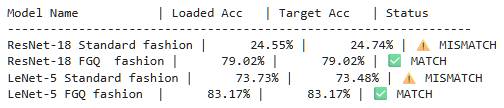

### Simpan ke pt


In [ ]:
# ==============================================
# LOAD & KONVERSI SAFETENSORS KE TORCHSCRIPT (.pt)
# ==============================================

import torch
import os
from safetensors.torch import load_file

# Path folder model
base_dir = '/content/drive/MyDrive/model_modular'
safetensors_dir = os.path.join(base_dir, 'safetensors_models')
export_dir = os.path.join(base_dir, 'torchscript_models')
os.makedirs(export_dir, exist_ok=True)

# ==============================================
# 1. DEFINISIKAN ULANG MODEL (sama seperti di notebook)
# ==============================================

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = nn.functional.avg_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = nn.functional.avg_pool2d(x, 2)
        x = x.view(-1, 16 * 5 * 5)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()
        from torchvision import models
        self.model = models.resnet18(weights=None)
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.model(x)

# ==============================================
# 2. LOAD DARI SAFETENSORS DAN KONVERSI KE .pt
# ==============================================

def convert_safetensors_to_pt(safetensors_path, model_class, export_name, device='cpu'):
    """
    Load model dari .safetensors dan ekspor ke .pt (TorchScript)
    """
    print(f"\n📦 Converting: {export_name}")

    # Buat model template
    template_model = model_class().to(device)

    # Load dari safetensors
    print(f"   Loading from: {safetensors_path}")
    model = load_ternary_safetensors(safetensors_path, template_model)
    model.to(device)
    model.eval()

    # Trace dengan contoh input
    example_input = torch.randn(1, 1, 28, 28).to(device)
    traced_model = torch.jit.trace(model, example_input)

    # Simpan ke .pt
    export_path = os.path.join(export_dir, f"{export_name}.pt")
    # traced_model.save(export_path)
    torch.jit.save(traced_model, export_path, _extra_files=None)
    print(f"✅ Saved to: {export_path}")

    return traced_model

# ==============================================
# 3. EKSEKUSI KONVERSI
# ==============================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Device: {device}")

# Daftar model yang akan dikonversi
models_to_convert = [
    # (nama_file_safetensors, model_class, nama_export)
    ('lenet5_standard_fashion.safetensors', LeNet5, 'lenet5_standard_fashion'),
    ('lenet5_fgq_fashion.safetensors', LeNet5, 'lenet5_fgq_fashion'),
    ('resnet18_standard_fashion.safetensors', ResNet18, 'resnet18_standard_fashion'),
    ('resnet18_fgq_fashion.safetensors', ResNet18, 'resnet18_fgq_fashion'),
]

print("="*60)
print("🚀 CONVERTING SAFETENSORS TO TORCHSCRIPT")
print("="*60)

for safetensors_file, model_class, export_name in models_to_convert:
    safetensors_path = os.path.join(safetensors_dir, safetensors_file)

    if not os.path.exists(safetensors_path):
        print(f"⚠️ File not found: {safetensors_path}")
        continue

    try:
        convert_safetensors_to_pt(safetensors_path, model_class, export_name, device)
    except Exception as e:
        print(f"❌ Error converting {export_name}: {e}")

print("\n" + "="*60)
print("✅ ALL CONVERSIONS COMPLETE!")
print(f"📁 Output: {export_dir}")

🔥 Device: cpu
🚀 CONVERTING SAFETENSORS TO TORCHSCRIPT

📦 Converting: lenet5_standard_fashion
   Loading from: /content/drive/MyDrive/model_modular/safetensors_models/lenet5_standard_fashion.safetensors
✅ Saved to: /content/drive/MyDrive/model_modular/torchscript_models/lenet5_standard_fashion.pt

📦 Converting: lenet5_fgq_fashion
   Loading from: /content/drive/MyDrive/model_modular/safetensors_models/lenet5_fgq_fashion.safetensors
✅ Saved to: /content/drive/MyDrive/model_modular/torchscript_models/lenet5_fgq_fashion.pt

📦 Converting: resnet18_standard_fashion
   Loading from: /content/drive/MyDrive/model_modular/safetensors_models/resnet18_standard_fashion.safetensors
✅ Saved to: /content/drive/MyDrive/model_modular/torchscript_models/resnet18_standard_fashion.pt

📦 Converting: resnet18_fgq_fashion
   Loading from: /content/drive/MyDrive/model_modular/safetensors_models/resnet18_fgq_fashion.safetensors
✅ Saved to: /content/drive/MyDrive/model_modular/torchscript_models/resnet18_fgq_fas

In [ ]:
# Ekspor ulang semua model dengan torch.jit.save
import torch
import os

export_dir = '/content/drive/MyDrive/model_modular/torchscript_models'
os.makedirs(export_dir, exist_ok=True)

models_to_export = [
    (model_ternary_lenet, 'lenet5_standard_fashion'),
    # (best_model_fgq_lenet, 'lenet5_fgq_fashion'),
    (model_ternary_resnet, 'resnet18_standard_fashion'),
    # (best_model_fgq_resnet, 'resnet18_fgq_fashion'),
]

for model, name in models_to_export:
    model.eval()
    example_input = torch.randn(1, 1, 28, 28).to(device)

    # Gunakan torch.jit.script (lebih robust dari trace)
    scripted_model = torch.jit.script(model)

    # Simpan
    path = os.path.join(export_dir, f"{name}.pt")
    torch.jit.save(scripted_model, path)
    print(f"✅ Exported: {path}")

✅ Exported: /content/drive/MyDrive/model_modular/torchscript_models/lenet5_standard_fashion.pt
✅ Exported: /content/drive/MyDrive/model_modular/torchscript_models/resnet18_standard_fashion.pt


# **INFERENSI**

---



#### ResNet-18 Standard

In [ ]:
import torch
import time
import numpy as np
from PIL import Image
from google.colab import files
import os

# ==========================================
# 1. KONFIGURASI FASHION-MNIST
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Menggunakan device: {device}")

# Parameter normalisasi standar Fashion-MNIST
FMNIST_MEAN = 0.2860
FMNIST_STD = 0.3530

# Mapping label Fashion-MNIST ke nama kelas
FASHION_LABELS = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

base_dir = '/content/drive/MyDrive/model_modular'
baseline_path = os.path.join(base_dir, 'resnet18_fashion_baseline.pth')
quantized_path = os.path.join(base_dir, 'safetensors_models', 'resnet18_standard_fashion.safetensors')

# ==========================================
# 2. LOAD MODEL BASELINE (FP32) - FASHION
# ==========================================
print("\n📦 Memuat model Baseline Fashion-MNIST (FP32)...")
model_baseline = ResNet18().to(device)
checkpoint = torch.load(baseline_path, map_location=device)
model_baseline.load_state_dict(checkpoint['model_state_dict'])
model_baseline.eval()
print("✅ Baseline siap.")

# ==========================================
# 3. LOAD MODEL KUANTISASI (FASHION)
# ==========================================
print("\n📦 Memuat model Kuantisasi Fashion-MNIST (Standard Ternary)...")
model_quant = load_ternary_safetensors(quantized_path, ResNet18()).to(device)
model_quant.eval()
print("✅ Model kuantisasi siap.")

# ==========================================
# 4. FUNGSI BENCHMARK KECEPATAN
# ==========================================
def benchmark_speed(model, input_tensor, num_runs=100, warmup_runs=20):
    """Mengukur kecepatan inferensi rata-rata (ms dan FPS)."""
    # Warmup
    for _ in range(warmup_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    start_time = time.time()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    end_time = time.time()

    total_time_s = end_time - start_time
    avg_time_ms = (total_time_s / num_runs) * 1000
    fps = 1000 / avg_time_ms
    return avg_time_ms, fps

🔥 Menggunakan device: cpu

📦 Memuat model Baseline Fashion-MNIST (FP32)...
✅ Baseline siap.

📦 Memuat model Kuantisasi Fashion-MNIST (Standard Ternary)...
✅ Model kuantisasi siap.


In [ ]:
# ==========================================
# 1. UPLOAD GAMBAR CUSTOM
# ==========================================
print("📤 Silakan upload gambar fashion (sepatu, baju, tas, dll) format JPG/PNG:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print(f"✅ Berhasil upload: {image_path}")

# ==========================================
# 2. FUNGSI PREPROSES (FASHION-MNIST STANDARD)
# ==========================================
def preprocess_fashion_image(path, mean=FMNIST_MEAN, std=FMNIST_STD):
    img = Image.open(path).convert('L')
    img = img.resize((28, 28), Image.Resampling.LANCZOS)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_tensor = (img_array - mean) / std
    img_tensor = torch.from_numpy(img_tensor).unsqueeze(0).unsqueeze(0)
    return img_tensor.to(device)

input_tensor = preprocess_fashion_image(image_path)
print(f"✅ Shape input tensor: {input_tensor.shape}")

# ==========================================
# 3. EKSEKUSI BENCHMARK & PREDIKSI
# ==========================================
print("\n" + "="*60)
print("🚀 Benchmarking Kecepatan Inferensi - Fashion-MNIST")
print("="*60)

print("\n🔹 Baseline (FP32):")
avg_t, fps = benchmark_speed(model_baseline, input_tensor)
with torch.no_grad():
    pred_idx = model_baseline(input_tensor).argmax().item()
    pred_label = FASHION_LABELS[pred_idx]
print(f"   ⏱️  Rata-rata waktu: {avg_t:.4f} ms")
print(f"   📈 FPS: {fps:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label} (index {pred_idx})")

print("\n🔹 Kuantisasi Standard Ternary:")
avg_t_q, fps_q = benchmark_speed(model_quant, input_tensor)
with torch.no_grad():
    pred_idx_q = model_quant(input_tensor).argmax().item()
    pred_label_q = FASHION_LABELS[pred_idx_q]
print(f"   ⏱️  Rata-rata waktu: {avg_t_q:.4f} ms")
print(f"   📈 FPS: {fps_q:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label_q} (index {pred_idx_q})")

# ==========================================
# 4. PERBANDINGAN SPEEDUP & VERIFIKASI
# ==========================================
speedup = avg_t / avg_t_q
print("\n" + "="*60)
print("📊 RINGKASAN PERBANDINGAN")
print("="*60)
print(f"⚡ Speedup (Baseline vs Kuantisasi): {speedup:.2f}x lebih cepat")
print(f"✅ Hasil prediksi sama? {'Ya ✅' if pred_idx == pred_idx_q else 'Tidak ❌'}")

try:
    from IPython.display import display
    print("\n🖼️ Gambar yang diupload:")
    display(Image.open(image_path))
except:
    pass

📤 Silakan upload gambar fashion (sepatu, baju, tas, dll) format JPG/PNG:


Saving 0.png to 0 (1).png
✅ Berhasil upload: 0 (1).png
✅ Shape input tensor: torch.Size([1, 1, 28, 28])

🚀 Benchmarking Kecepatan Inferensi - Fashion-MNIST

🔹 Baseline (FP32):
   ⏱️  Rata-rata waktu: 8.9556 ms
   📈 FPS: 111.66 gambar/detik
   🎯 Prediksi: Ankle boot (index 9)

🔹 Kuantisasi Standard Ternary:
   ⏱️  Rata-rata waktu: 10.5107 ms
   📈 FPS: 95.14 gambar/detik
   🎯 Prediksi: Bag (index 8)

📊 RINGKASAN PERBANDINGAN
⚡ Speedup (Baseline vs Kuantisasi): 0.85x lebih cepat
✅ Hasil prediksi sama? Tidak ❌

🖼️ Gambar yang diupload:


#### ResNet-18 Fine-Grained

In [ ]:
import torch
import time
import numpy as np
from PIL import Image
from google.colab import files
import os

# ==========================================
# 1. KONFIGURASI FASHION-MNIST
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Menggunakan device: {device}")

# Parameter normalisasi standar Fashion-MNIST
FMNIST_MEAN = 0.2860
FMNIST_STD = 0.3530

# Mapping label Fashion-MNIST ke nama kelas
FASHION_LABELS = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

base_dir = '/content/drive/MyDrive/model_modular'
baseline_path_fgq = os.path.join(base_dir, 'resnet18_fashion_baseline.pth')
quantized_path_fgq = os.path.join(base_dir, 'safetensors_models', 'resnet18_fgq_fashion.safetensors')

# ==========================================
# 2. LOAD MODEL BASELINE (FP32) - FASHION
# ==========================================
print("\n📦 Memuat model Baseline Fashion-MNIST (FP32)...")
model_baseline = ResNet18().to(device)
checkpoint = torch.load(baseline_path, map_location=device)
model_baseline.load_state_dict(checkpoint['model_state_dict'])
model_baseline.eval()
print("✅ Baseline siap.")

# ==========================================
# 3. LOAD MODEL KUANTISASI (FASHION)
# ==========================================
print("\n📦 Memuat model Kuantisasi Fashion-MNIST (Fine-Grained Ternary)...")
model_quant_fgq = load_ternary_safetensors(quantized_path, ResNet18()).to(device)
model_quant_fgq.eval()
print("✅ Model kuantisasi siap.")

# ==========================================
# 4. FUNGSI BENCHMARK KECEPATAN
# ==========================================
def benchmark_speed(model, input_tensor, num_runs=100, warmup_runs=20):
    """Mengukur kecepatan inferensi rata-rata (ms dan FPS)."""
    # Warmup
    for _ in range(warmup_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    start_time = time.time()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    end_time = time.time()

    total_time_s = end_time - start_time
    avg_time_ms = (total_time_s / num_runs) * 1000
    fps = 1000 / avg_time_ms
    return avg_time_ms, fps

In [ ]:
# ==========================================
# 1. UPLOAD GAMBAR CUSTOM
# ==========================================
print("📤 Silakan upload gambar fashion (sepatu, baju, tas, dll) format JPG/PNG:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print(f"✅ Berhasil upload: {image_path}")

# ==========================================
# 2. FUNGSI PREPROSES (FASHION-MNIST STANDARD)
# ==========================================
def preprocess_fashion_image(path, mean=FMNIST_MEAN, std=FMNIST_STD):
    img = Image.open(path).convert('L')
    img = img.resize((28, 28), Image.Resampling.LANCZOS)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_tensor = (img_array - mean) / std
    img_tensor = torch.from_numpy(img_tensor).unsqueeze(0).unsqueeze(0)
    return img_tensor.to(device)

input_tensor = preprocess_fashion_image(image_path)
print(f"✅ Shape input tensor: {input_tensor.shape}")

# ==========================================
# 3. EKSEKUSI BENCHMARK & PREDIKSI
# ==========================================
print("\n" + "="*60)
print("🚀 Benchmarking Kecepatan Inferensi - Fashion-MNIST")
print("="*60)

print("\n🔹 Baseline (FP32):")
avg_t, fps = benchmark_speed(model_baseline, input_tensor)
with torch.no_grad():
    pred_idx = model_baseline(input_tensor).argmax().item()
    pred_label = FASHION_LABELS[pred_idx]
print(f"   ⏱️  Rata-rata waktu: {avg_t:.4f} ms")
print(f"   📈 FPS: {fps:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label} (index {pred_idx})")

print("\n🔹 Kuantisasi Fine-Grained Ternary:")
avg_t_q, fps_q = benchmark_speed(model_quant_fgq, input_tensor)
with torch.no_grad():
    pred_idx_q = model_quant_fgq(input_tensor).argmax().item()
    pred_label_q = FASHION_LABELS[pred_idx_q]
print(f"   ⏱️  Rata-rata waktu: {avg_t_q:.4f} ms")
print(f"   📈 FPS: {fps_q:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label_q} (index {pred_idx_q})")

# ==========================================
# 4. PERBANDINGAN SPEEDUP & VERIFIKASI
# ==========================================
speedup = avg_t / avg_t_q
print("\n" + "="*60)
print("📊 RINGKASAN PERBANDINGAN")
print("="*60)
print(f"⚡ Speedup (Baseline vs Kuantisasi): {speedup:.2f}x lebih cepat")
print(f"✅ Hasil prediksi sama? {'Ya ✅' if pred_idx == pred_idx_q else 'Tidak ❌'}")

try:
    from IPython.display import display
    print("\n🖼️ Gambar yang diupload:")
    display(Image.open(image_path))
except:
    pass

#### LeNet-5 Standard

In [ ]:
import torch
import time
import numpy as np
from PIL import Image
from google.colab import files
import os

# ==========================================
# 1. KONFIGURASI FASHION-MNIST
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Menggunakan device: {device}")

# Parameter normalisasi standar Fashion-MNIST
# FMNIST_MEAN = 0.2860
# FMNIST_STD = 0.3530
FMNIST_MEAN = 0.5
FMNIST_STD = 0.5

# Mapping label Fashion-MNIST ke nama kelas
FASHION_LABELS = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

base_dir = '/content/drive/MyDrive/model_modular'
baseline_path = os.path.join(base_dir, 'lenet5_fashion_baseline.pth')
quantized_path = os.path.join(base_dir, 'safetensors_models', 'lenet5_standard_fashion.safetensors')

# ==========================================
# 2. LOAD MODEL BASELINE (FP32) - FASHION
# ==========================================
print("\n📦 Memuat model Baseline Fashion-MNIST (FP32)...")
model_baseline = LeNet5().to(device)
checkpoint = torch.load(baseline_path, map_location=device)
model_baseline.load_state_dict(checkpoint['model_state_dict'])
model_baseline.eval()
print("✅ Baseline siap.")

# ==========================================
# 3. LOAD MODEL KUANTISASI (FASHION)
# ==========================================
print("\n📦 Memuat model Kuantisasi Fashion-MNIST (Standard Ternary)...")
model_quant = load_ternary_safetensors(quantized_path, LeNet5()).to(device)
model_quant.eval()
print("✅ Model kuantisasi siap.")

# ==========================================
# 4. FUNGSI BENCHMARK KECEPATAN
# ==========================================
def benchmark_speed(model, input_tensor, num_runs=100, warmup_runs=20):
    """Mengukur kecepatan inferensi rata-rata (ms dan FPS)."""
    # Warmup
    for _ in range(warmup_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    start_time = time.time()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    end_time = time.time()

    total_time_s = end_time - start_time
    avg_time_ms = (total_time_s / num_runs) * 1000
    fps = 1000 / avg_time_ms
    return avg_time_ms, fps

🔥 Menggunakan device: cpu

📦 Memuat model Baseline Fashion-MNIST (FP32)...
✅ Baseline siap.

📦 Memuat model Kuantisasi Fashion-MNIST (Standard Ternary)...
✅ Model kuantisasi siap.


In [ ]:
# ==========================================
# 1. UPLOAD GAMBAR CUSTOM
# ==========================================
print("📤 Silakan upload gambar fashion (sepatu, baju, tas, dll) format JPG/PNG:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print(f"✅ Berhasil upload: {image_path}")

# ==========================================
# 2. FUNGSI PREPROSES (FASHION-MNIST STANDARD)
# ==========================================
def preprocess_fashion_image(path, mean=FMNIST_MEAN, std=FMNIST_STD):
    img = Image.open(path).convert('L')
    img = img.resize((28, 28), Image.Resampling.LANCZOS)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_tensor = (img_array - mean) / std
    img_tensor = torch.from_numpy(img_tensor).unsqueeze(0).unsqueeze(0)
    return img_tensor.to(device)

input_tensor = preprocess_fashion_image(image_path)
print(f"✅ Shape input tensor: {input_tensor.shape}")


# ==========================================
# 3. EKSEKUSI BENCHMARK & PREDIKSI
# ==========================================
print("\n" + "="*60)
print("🚀 Benchmarking Kecepatan Inferensi - Fashion-MNIST")
print("="*60)

print("\n🔹 Baseline (FP32):")
avg_t, fps = benchmark_speed(model_baseline, input_tensor)
with torch.no_grad():
    pred_idx = model_baseline(input_tensor).argmax().item()
    pred_label = FASHION_LABELS[pred_idx]
print(f"   ⏱️  Rata-rata waktu: {avg_t:.4f} ms")
print(f"   📈 FPS: {fps:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label} (index {pred_idx})")

print("\n🔹 Kuantisasi Standard Ternary:")
avg_t_q, fps_q = benchmark_speed(model_quant, input_tensor)
with torch.no_grad():
    pred_idx_q = model_quant(input_tensor).argmax().item()
    pred_label_q = FASHION_LABELS[pred_idx_q]
print(f"   ⏱️  Rata-rata waktu: {avg_t_q:.4f} ms")
print(f"   📈 FPS: {fps_q:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label_q} (index {pred_idx_q})")

# ==========================================
# 4. PERBANDINGAN SPEEDUP & VERIFIKASI
# ==========================================
speedup = avg_t / avg_t_q
print("\n" + "="*60)
print("📊 RINGKASAN PERBANDINGAN")
print("="*60)
print(f"⚡ Speedup (Baseline vs Kuantisasi): {speedup:.2f}x lebih cepat")
print(f"✅ Hasil prediksi sama? {'Ya ✅' if pred_idx == pred_idx_q else 'Tidak ❌'}")

try:
    from IPython.display import display
    print("\n🖼️ Gambar yang diupload:")
    display(Image.open(image_path))
except:
    pass

📤 Silakan upload gambar fashion (sepatu, baju, tas, dll) format JPG/PNG:


Saving 0.png to 0.png
✅ Berhasil upload: 0.png
✅ Shape input tensor: torch.Size([1, 1, 28, 28])

🚀 Benchmarking Kecepatan Inferensi - Fashion-MNIST

🔹 Baseline (FP32):
   ⏱️  Rata-rata waktu: 0.3039 ms
   📈 FPS: 3290.37 gambar/detik
   🎯 Prediksi: Ankle boot (index 9)

🔹 Kuantisasi Standard Ternary:
   ⏱️  Rata-rata waktu: 0.2855 ms
   📈 FPS: 3502.17 gambar/detik
   🎯 Prediksi: Ankle boot (index 9)

📊 RINGKASAN PERBANDINGAN
⚡ Speedup (Baseline vs Kuantisasi): 1.06x lebih cepat
✅ Hasil prediksi sama? Ya ✅

🖼️ Gambar yang diupload:


#### LeNet-5 Fine-Grained

In [ ]:
import torch
import time
import numpy as np
from PIL import Image
from google.colab import files
import os

# ==========================================
# 1. KONFIGURASI FASHION-MNIST
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Menggunakan device: {device}")

# Parameter normalisasi standar Fashion-MNIST
FMNIST_MEAN = 0.2860
FMNIST_STD = 0.3530

# Mapping label Fashion-MNIST ke nama kelas
FASHION_LABELS = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

base_dir = '/content/drive/MyDrive/model_modular'
baseline_path = os.path.join(base_dir, 'lenet5_fashion_baseline.pth')
quantized_path_fgq = os.path.join(base_dir, 'safetensors_models', 'lenet5_fgq_fashion.safetensors')

# ==========================================
# 2. LOAD MODEL BASELINE (FP32) - FASHION
# ==========================================
print("\n📦 Memuat model Baseline Fashion-MNIST (FP32)...")
model_baseline = LeNet5().to(device)  # arsitektur sama
checkpoint = torch.load(baseline_path, map_location=device)
model_baseline.load_state_dict(checkpoint['model_state_dict'])
model_baseline.eval()
print("✅ Baseline siap.")

# ==========================================
# 3. LOAD MODEL KUANTISASI (FASHION)
# ==========================================
print("\n📦 Memuat model Kuantisasi Fashion-MNIST (Fine-Grained Ternary)...")
model_quant_fgq = load_ternary_safetensors(quantized_path_fgq, LeNet5()).to(device)
model_quant_fgq.eval()
print("✅ Model kuantisasi siap.")

# ==========================================
# 4. FUNGSI BENCHMARK KECEPATAN
# ==========================================
def benchmark_speed(model, input_tensor, num_runs=100, warmup_runs=20):
    """Mengukur kecepatan inferensi rata-rata (ms dan FPS)."""
    # Warmup
    for _ in range(warmup_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    start_time = time.time()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    end_time = time.time()

    total_time_s = end_time - start_time
    avg_time_ms = (total_time_s / num_runs) * 1000
    fps = 1000 / avg_time_ms
    return avg_time_ms, fps

In [ ]:
# ==========================================
# 1. UPLOAD GAMBAR CUSTOM
# ==========================================
print("📤 Silakan upload gambar fashion (sepatu, baju, tas, dll) format JPG/PNG:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print(f"✅ Berhasil upload: {image_path}")

# ==========================================
# 2. FUNGSI PREPROSES (FASHION-MNIST FINE-GRAINED)
# ==========================================
def preprocess_fashion_image(path, mean=FMNIST_MEAN, std=FMNIST_STD):
    img = Image.open(path).convert('L')
    img = img.resize((28, 28), Image.Resampling.LANCZOS)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_tensor = (img_array - mean) / std
    img_tensor = torch.from_numpy(img_tensor).unsqueeze(0).unsqueeze(0)
    return img_tensor.to(device)

input_tensor = preprocess_fashion_image(image_path)
print(f"✅ Shape input tensor: {input_tensor.shape}")


# ==========================================
# 3. EKSEKUSI BENCHMARK & PREDIKSI
# ==========================================
print("\n" + "="*60)
print("🚀 Benchmarking Kecepatan Inferensi - Fashion-MNIST")
print("="*60)

print("\n🔹 Baseline (FP32):")
avg_t, fps = benchmark_speed(model_baseline, input_tensor)
with torch.no_grad():
    pred_idx = model_baseline(input_tensor).argmax().item()
    pred_label = FASHION_LABELS[pred_idx]
print(f"   ⏱️  Rata-rata waktu: {avg_t:.4f} ms")
print(f"   📈 FPS: {fps:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label} (index {pred_idx})")

print("\n🔹 Kuantisasi Fine-Grained Ternary:")
avg_t_q, fps_q = benchmark_speed(model_quant_fgq, input_tensor)
with torch.no_grad():
    pred_idx_q = model_quant_fgq(input_tensor).argmax().item()
    pred_label_q = FASHION_LABELS[pred_idx_q]
print(f"   ⏱️  Rata-rata waktu: {avg_t_q:.4f} ms")
print(f"   📈 FPS: {fps_q:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label_q} (index {pred_idx_q})")

# ==========================================
# 4. PERBANDINGAN SPEEDUP & VERIFIKASI
# ==========================================
speedup = avg_t / avg_t_qinsins
print("\n" + "="*60)
print("📊 RINGKASAN PERBANDINGAN")
print("="*60)
print(f"⚡ Speedup (Baseline vs Kuantisasi): {speedup:.2f}x lebih cepat")
print(f"✅ Hasil prediksi sama? {'Ya ✅' if pred_idx == pred_idx_q else 'Tidak ❌'}")

try:
    from IPython.display import display
    print("\n🖼️ Gambar yang diupload:")
    display(Image.open(image_path))
except:
    pass

# INFERENSI V2


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import copy

# Pastikan kelas Q2Linear dan Q2Conv2d yang sebelumnya sudah didefinisikan tetap ada di notebook Anda.

def convert_to_q2_model(model, group_size=4, standard_ternary=False):
    """
    Mengonversi model PyTorch standar menjadi model Q2-MatMul.
    - standard_ternary=False: Untuk model FGQ (gunakan group_size kecil seperti 4, 8, 16).
    - standard_ternary=True: Untuk model Standard (otomatis menggunakan seluruh layer sebagai 1 grup).
    """
    new_model = copy.deepcopy(model)

    for name, module in new_model.named_modules():
        if isinstance(module, (nn.Linear, nn.Conv2d)):
            w = module.weight.data
            numel = w.numel()

            # Jika Standard Ternary, seluruh layer adalah 1 grup
            gs = numel if standard_ternary else group_size
            num_groups = (numel + gs - 1) // gs

            # Inisialisasi layer Q2 yang sesuai
            if isinstance(module, nn.Linear):
                new_layer = Q2Linear(module.in_features, module.out_features, group_size=gs, bias=module.bias is not None)
            else: # nn.Conv2d
                new_layer = Q2Conv2d(module.in_channels, module.out_channels, module.kernel_size[0],
                                     stride=module.stride[0], padding=module.padding[0],
                                     group_size=gs, bias=module.bias is not None)

            # 1. Ekstrak Mask Q2 (-1, 0, 1)
            mask = torch.zeros_like(w, dtype=torch.int8)
            mask[w > 0] = 1
            mask[w < 0] = -1
            new_layer.weight_mask = mask

            # 2. Ekstrak Skala Asimetris per Grup
            w_flat = w.flatten()
            scales = []
            for i in range(num_groups):
                start = i * gs
                end = min((i + 1) * gs, numel)
                group = w_flat[start:end]

                pos_vals = group[group > 0]
                neg_vals = group[group < 0]

                s_pos = pos_vals.abs().mean().item() if pos_vals.numel() > 0 else 0.0
                s_neg = neg_vals.abs().mean().item() if neg_vals.numel() > 0 else 0.0
                scales.append([s_pos, s_neg])

            new_layer.weight_scale = torch.tensor(scales, dtype=torch.float32)

            if module.bias is not None:
                new_layer.bias = module.bias.data.clone()

            # Replace layer (menangani nama layer dengan atau tanpa titik)
            if '.' in name:
                parent_name = name.rsplit('.', 1)[0]
                child_name = name.rsplit('.', 1)[1]
                parent = new_model.get_submodule(parent_name)
            else:
                parent = new_model
                child_name = name

            setattr(parent, child_name, new_layer)

    return new_model

In [ ]:
print("--- Mengonversi Model ke Arsitektur Q2-MatMul ---")

# Gunakan group_size terbaik yang ditemukan sebelumnya (misal: 4 untuk ResNet, 16 untuk LeNet)
# Pastikan variabel best_gs_resnet dan best_gs_lenet sudah ada dari sel sebelumnya
q2_model_resnet = convert_to_q2_model(best_model_fgq_resnet, group_size=best_gs_resnet).to(device)
q2_model_lenet = convert_to_q2_model(best_model_fgq_lenet, group_size=best_gs_lenet).to(device)

print("✅ Konversi selesai. Model sekarang menggunakan int8 Mask & Asymmetric Scales (Q2 Representation).")

# Verifikasi Akurasi
print("\n--- Verifikasi Akurasi Inferensi Q2 ---")
acc_q2_resnet = evaluate_accuracy(q2_model_resnet, test_loader_resnet, device)
acc_q2_lenet = evaluate_accuracy(q2_model_lenet, test_loader_lenet, device)

print(f"ResNet-18 FGQ Target : {best_acc_resnet:.2f}%")
print(f"ResNet-18 Q2 Inference: {acc_q2_resnet:.2f}% {'✅ MATCH' if abs(acc_q2_resnet - best_acc_resnet) < 0.1 else '⚠️ MISMATCH'}")

print(f"\nLeNet-5 FGQ Target   : {best_acc_lenet:.2f}%")
print(f"LeNet-5 Q2 Inference : {acc_q2_lenet:.2f}% {'✅ MATCH' if abs(acc_q2_lenet - best_acc_lenet) < 0.1 else '⚠️ MISMATCH'}")

#### ResNet-18 Standard V2

In [ ]:
import torch
import time
import numpy as np
from PIL import Image
from google.colab import files
import os

# ==========================================
# 1. KONFIGURASI FASHION-MNIST
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Menggunakan device: {device}")

# Parameter normalisasi standar Fashion-MNIST
FMNIST_MEAN = 0.2860
FMNIST_STD = 0.3530

# Mapping label Fashion-MNIST ke nama kelas
FASHION_LABELS = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

base_dir = '/content/drive/MyDrive/model_modular'
baseline_path = os.path.join(base_dir, 'resnet18_fashion_baseline.pth')
quantized_path = os.path.join(base_dir, 'safetensors_models', 'resnet18_standard_fashion.safetensors')

# ==========================================
# 2. LOAD MODEL BASELINE (FP32) - FASHION
# ==========================================
print("\n📦 Memuat model Baseline Fashion-MNIST (FP32)...")
model_baseline = ResNet18().to(device)
checkpoint = torch.load(baseline_path, map_location=device)
model_baseline.load_state_dict(checkpoint['model_state_dict'])
model_baseline.eval()
print("✅ Baseline siap.")

# ==========================================
# 3. LOAD MODEL KUANTISASI (FASHION)
# ==========================================
print("\n📦 Memuat model Kuantisasi Fashion-MNIST (Standard Ternary)...")
# Gunakan standard_ternary=True agar seluruh layer jadi 1 grup
model_quant_resnet = convert_to_q2_model(model_ternary_resnet, standard_ternary=True).to(device)
model_quant_resnet.eval()
print("✅ Model kuantisasi siap.")

# ==========================================
# 4. FUNGSI BENCHMARK KECEPATAN
# ==========================================
def benchmark_speed(model, input_tensor, num_runs=100, warmup_runs=20):
    """Mengukur kecepatan inferensi rata-rata (ms dan FPS)."""
    # Warmup
    for _ in range(warmup_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    start_time = time.time()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    end_time = time.time()

    total_time_s = end_time - start_time
    avg_time_ms = (total_time_s / num_runs) * 1000
    fps = 1000 / avg_time_ms
    return avg_time_ms, fps

In [ ]:
# ==========================================
# 1. UPLOAD GAMBAR CUSTOM
# ==========================================
print("📤 Silakan upload gambar fashion (sepatu, baju, tas, dll) format JPG/PNG:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print(f"✅ Berhasil upload: {image_path}")

# ==========================================
# 2. FUNGSI PREPROSES (FASHION-MNIST STANDARD)
# ==========================================
def preprocess_fashion_image(path, mean=FMNIST_MEAN, std=FMNIST_STD):
    img = Image.open(path).convert('L')
    img = img.resize((28, 28), Image.Resampling.LANCZOS)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_tensor = (img_array - mean) / std
    img_tensor = torch.from_numpy(img_tensor).unsqueeze(0).unsqueeze(0)
    return img_tensor.to(device)

input_tensor = preprocess_fashion_image(image_path)
print(f"✅ Shape input tensor: {input_tensor.shape}")

# ==========================================
# 3. EKSEKUSI BENCHMARK & PREDIKSI
# ==========================================
print("\n" + "="*60)
print("🚀 Benchmarking Kecepatan Inferensi - Fashion-MNIST")
print("="*60)

print("\n🔹 Baseline (FP32):")
avg_t, fps = benchmark_speed(model_baseline, input_tensor)
with torch.no_grad():
    pred_idx = model_baseline(input_tensor).argmax().item()
    pred_label = FASHION_LABELS[pred_idx]
print(f"   ⏱️  Rata-rata waktu: {avg_t:.4f} ms")
print(f"   📈 FPS: {fps:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label} (index {pred_idx})")

print("\n🔹 Kuantisasi Standard Ternary:")
avg_t_q, fps_q = benchmark_speed(model_quant_resnet, input_tensor)
with torch.no_grad():
    pred_idx_q = model_quant_resnet(input_tensor).argmax().item()
    pred_label_q = FASHION_LABELS[pred_idx_q]
print(f"   ⏱️  Rata-rata waktu: {avg_t_q:.4f} ms")
print(f"   📈 FPS: {fps_q:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label_q} (index {pred_idx_q})")

# ==========================================
# 4. PERBANDINGAN SPEEDUP & VERIFIKASI
# ==========================================
speedup = avg_t / avg_t_q
print("\n" + "="*60)
print("📊 RINGKASAN PERBANDINGAN")
print("="*60)
print(f"⚡ Speedup (Baseline vs Kuantisasi): {speedup:.2f}x lebih cepat")
print(f"✅ Hasil prediksi sama? {'Ya ✅' if pred_idx == pred_idx_q else 'Tidak ❌'}")

try:
    from IPython.display import display
    print("\n🖼️ Gambar yang diupload:")
    display(Image.open(image_path))
except:
    pass

#### ResNet-18 Fine-Grained V2

In [ ]:
import torch
import time
import numpy as np
from PIL import Image
from google.colab import files
import os

# ==========================================
# 1. KONFIGURASI FASHION-MNIST
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Menggunakan device: {device}")

# Parameter normalisasi standar Fashion-MNIST
FMNIST_MEAN = 0.2860
FMNIST_STD = 0.3530

# Mapping label Fashion-MNIST ke nama kelas
FASHION_LABELS = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

base_dir = '/content/drive/MyDrive/model_modular'
baseline_path_fgq = os.path.join(base_dir, 'resnet18_fashion_baseline.pth')
quantized_path_fgq = os.path.join(base_dir, 'safetensors_models', 'resnet18_fgq_fashion.safetensors')

# ==========================================
# 2. LOAD MODEL BASELINE (FP32) - FASHION
# ==========================================
print("\n📦 Memuat model Baseline Fashion-MNIST (FP32)...")
model_baseline = ResNet18().to(device)
checkpoint = torch.load(baseline_path, map_location=device)
model_baseline.load_state_dict(checkpoint['model_state_dict'])
model_baseline.eval()
print("✅ Baseline siap.")

# ==========================================
# 3. LOAD MODEL KUANTISASI (FASHION)
# ==========================================
print("\n📦 Memuat model Kuantisasi Fashion-MNIST (Fine-Grained Ternary)...")
# Gunakan group_size terbaik (misal 4) dan standard_ternary=False
model_quant_fgq_resnet = convert_to_q2_model(best_model_fgq_resnet, group_size=best_gs_resnet).to(device)
model_quant_fgq_resnet.eval()
print("✅ Model kuantisasi siap.")

# ==========================================
# 4. FUNGSI BENCHMARK KECEPATAN
# ==========================================
def benchmark_speed(model, input_tensor, num_runs=100, warmup_runs=20):
    """Mengukur kecepatan inferensi rata-rata (ms dan FPS)."""
    # Warmup
    for _ in range(warmup_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    start_time = time.time()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    end_time = time.time()

    total_time_s = end_time - start_time
    avg_time_ms = (total_time_s / num_runs) * 1000
    fps = 1000 / avg_time_ms
    return avg_time_ms, fps

In [ ]:
# ==========================================
# 1. UPLOAD GAMBAR CUSTOM
# ==========================================
print("📤 Silakan upload gambar fashion (sepatu, baju, tas, dll) format JPG/PNG:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print(f"✅ Berhasil upload: {image_path}")

# ==========================================
# 2. FUNGSI PREPROSES (FASHION-MNIST STANDARD)
# ==========================================
def preprocess_fashion_image(path, mean=FMNIST_MEAN, std=FMNIST_STD):
    img = Image.open(path).convert('L')
    img = img.resize((28, 28), Image.Resampling.LANCZOS)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_tensor = (img_array - mean) / std
    img_tensor = torch.from_numpy(img_tensor).unsqueeze(0).unsqueeze(0)
    return img_tensor.to(device)

input_tensor = preprocess_fashion_image(image_path)
print(f"✅ Shape input tensor: {input_tensor.shape}")

# ==========================================
# 3. EKSEKUSI BENCHMARK & PREDIKSI
# ==========================================
print("\n" + "="*60)
print("🚀 Benchmarking Kecepatan Inferensi - Fashion-MNIST")
print("="*60)

print("\n🔹 Baseline (FP32):")
avg_t, fps = benchmark_speed(model_baseline, input_tensor)
with torch.no_grad():
    pred_idx = model_baseline(input_tensor).argmax().item()
    pred_label = FASHION_LABELS[pred_idx]
print(f"   ⏱️  Rata-rata waktu: {avg_t:.4f} ms")
print(f"   📈 FPS: {fps:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label} (index {pred_idx})")

print("\n🔹 Kuantisasi Fine-Grained Ternary:")
avg_t_q, fps_q = benchmark_speed(model_quant_fgq_resnet, input_tensor)
with torch.no_grad():
    pred_idx_q = model_quant_fgq_resnet(input_tensor).argmax().item()
    pred_label_q = FASHION_LABELS[pred_idx_q]
print(f"   ⏱️  Rata-rata waktu: {avg_t_q:.4f} ms")
print(f"   📈 FPS: {fps_q:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label_q} (index {pred_idx_q})")

# ==========================================
# 4. PERBANDINGAN SPEEDUP & VERIFIKASI
# ==========================================
speedup = avg_t / avg_t_q
print("\n" + "="*60)
print("📊 RINGKASAN PERBANDINGAN")
print("="*60)
print(f"⚡ Speedup (Baseline vs Kuantisasi): {speedup:.2f}x lebih cepat")
print(f"✅ Hasil prediksi sama? {'Ya ✅' if pred_idx == pred_idx_q else 'Tidak ❌'}")

try:
    from IPython.display import display
    print("\n🖼️ Gambar yang diupload:")
    display(Image.open(image_path))
except:
    pass

#### LeNet-5 Standard

In [ ]:
import torch
import time
import numpy as np
from PIL import Image
from google.colab import files
import os

# ==========================================
# 1. KONFIGURASI FASHION-MNIST
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Menggunakan device: {device}")

# Parameter normalisasi standar Fashion-MNIST
FMNIST_MEAN = 0.2860
FMNIST_STD = 0.3530

# Mapping label Fashion-MNIST ke nama kelas
FASHION_LABELS = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

base_dir = '/content/drive/MyDrive/model_modular'
baseline_path = os.path.join(base_dir, 'lenet5_fashion_baseline.pth')
quantized_path = os.path.join(base_dir, 'safetensors_models', 'lenet5_standard_fashion.safetensors')

# ==========================================
# 2. LOAD MODEL BASELINE (FP32) - FASHION
# ==========================================
print("\n📦 Memuat model Baseline Fashion-MNIST (FP32)...")
model_baseline = LeNet5().to(device)
checkpoint = torch.load(baseline_path, map_location=device)
model_baseline.load_state_dict(checkpoint['model_state_dict'])
model_baseline.eval()
print("✅ Baseline siap.")

# ==========================================
# 3. LOAD MODEL KUANTISASI (FASHION)
# ==========================================
print("\n📦 Memuat model Kuantisasi Fashion-MNIST (Standard Ternary)...")
model_quant_lenet = convert_to_q2_model(model_ternary_lenet, standard_ternary=True).to(device)
model_quant_lenet.eval()
print("✅ Model kuantisasi siap.")

# ==========================================
# 4. FUNGSI BENCHMARK KECEPATAN
# ==========================================
def benchmark_speed(model, input_tensor, num_runs=100, warmup_runs=20):
    """Mengukur kecepatan inferensi rata-rata (ms dan FPS)."""
    # Warmup
    for _ in range(warmup_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    start_time = time.time()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    end_time = time.time()

    total_time_s = end_time - start_time
    avg_time_ms = (total_time_s / num_runs) * 1000
    fps = 1000 / avg_time_ms
    return avg_time_ms, fps

In [ ]:
# ==========================================
# 1. UPLOAD GAMBAR CUSTOM
# ==========================================
print("📤 Silakan upload gambar fashion (sepatu, baju, tas, dll) format JPG/PNG:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print(f"✅ Berhasil upload: {image_path}")

# ==========================================
# 2. FUNGSI PREPROSES (FASHION-MNIST STANDARD)
# ==========================================
def preprocess_fashion_image(path, mean=FMNIST_MEAN, std=FMNIST_STD):
    img = Image.open(path).convert('L')
    img = img.resize((28, 28), Image.Resampling.LANCZOS)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_tensor = (img_array - mean) / std
    img_tensor = torch.from_numpy(img_tensor).unsqueeze(0).unsqueeze(0)
    return img_tensor.to(device)

input_tensor = preprocess_fashion_image(image_path)
print(f"✅ Shape input tensor: {input_tensor.shape}")


# ==========================================
# 3. EKSEKUSI BENCHMARK & PREDIKSI
# ==========================================
print("\n" + "="*60)
print("🚀 Benchmarking Kecepatan Inferensi - Fashion-MNIST")
print("="*60)

print("\n🔹 Baseline (FP32):")
avg_t, fps = benchmark_speed(model_baseline, input_tensor)
with torch.no_grad():
    pred_idx = model_baseline(input_tensor).argmax().item()
    pred_label = FASHION_LABELS[pred_idx]
print(f"   ⏱️  Rata-rata waktu: {avg_t:.4f} ms")
print(f"   📈 FPS: {fps:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label} (index {pred_idx})")

print("\n🔹 Kuantisasi Standard Ternary:")
avg_t_q, fps_q = benchmark_speed(model_quant_lenet, input_tensor)
with torch.no_grad():
    pred_idx_q = model_quant_lenet(input_tensor).argmax().item()
    pred_label_q = FASHION_LABELS[pred_idx_q]
print(f"   ⏱️  Rata-rata waktu: {avg_t_q:.4f} ms")
print(f"   📈 FPS: {fps_q:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label_q} (index {pred_idx_q})")

# ==========================================
# 4. PERBANDINGAN SPEEDUP & VERIFIKASI
# ==========================================
speedup = avg_t / avg_t_q
print("\n" + "="*60)
print("📊 RINGKASAN PERBANDINGAN")
print("="*60)
print(f"⚡ Speedup (Baseline vs Kuantisasi): {speedup:.2f}x lebih cepat")
print(f"✅ Hasil prediksi sama? {'Ya ✅' if pred_idx == pred_idx_q else 'Tidak ❌'}")

try:
    from IPython.display import display
    print("\n🖼️ Gambar yang diupload:")
    display(Image.open(image_path))
except:
    pass

#### LeNet-5 Fine-Grained V2

In [ ]:
import torch
import time
import numpy as np
from PIL import Image
from google.colab import files
import os

# ==========================================
# 1. KONFIGURASI FASHION-MNIST
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Menggunakan device: {device}")

# Parameter normalisasi standar Fashion-MNIST
FMNIST_MEAN = 0.2860
FMNIST_STD = 0.3530

# Mapping label Fashion-MNIST ke nama kelas
FASHION_LABELS = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

base_dir = '/content/drive/MyDrive/model_modular'
baseline_path = os.path.join(base_dir, 'lenet5_fashion_baseline.pth')
quantized_path_fgq = os.path.join(base_dir, 'safetensors_models', 'lenet5_fgq_fashion.safetensors')

# ==========================================
# 2. LOAD MODEL BASELINE (FP32) - FASHION
# ==========================================
print("\n📦 Memuat model Baseline Fashion-MNIST (FP32)...")
model_baseline = LeNet5().to(device)  # arsitektur sama
checkpoint = torch.load(baseline_path, map_location=device)
model_baseline.load_state_dict(checkpoint['model_state_dict'])
model_baseline.eval()
print("✅ Baseline siap.")

# ==========================================
# 3. LOAD MODEL KUANTISASI (FASHION)
# ==========================================
print("\n📦 Memuat model Kuantisasi Fashion-MNIST (Fine-Grained Ternary)...")
# Kita pakai model yang sudah dikonversi, bukan load dari safetensors yang rekonstruksi ke float32
model_quant_fgq_lenet = convert_to_q2_model(best_model_fgq_lenet, group_size=best_gs_lenet).to(device)
model_quant_fgq_lenet.eval()
print("✅ Model kuantisasi siap.")

# ==========================================
# 4. FUNGSI BENCHMARK KECEPATAN
# ==========================================
def benchmark_speed(model, input_tensor, num_runs=100, warmup_runs=20):
    """Mengukur kecepatan inferensi rata-rata (ms dan FPS)."""
    # Warmup
    for _ in range(warmup_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    start_time = time.time()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    end_time = time.time()

    total_time_s = end_time - start_time
    avg_time_ms = (total_time_s / num_runs) * 1000
    fps = 1000 / avg_time_ms
    return avg_time_ms, fps

In [ ]:
# ==========================================
# 1. UPLOAD GAMBAR CUSTOM
# ==========================================
print("📤 Silakan upload gambar fashion (sepatu, baju, tas, dll) format JPG/PNG:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print(f"✅ Berhasil upload: {image_path}")

# ==========================================
# 2. FUNGSI PREPROSES (FASHION-MNIST FINE-GRAINED)
# ==========================================
def preprocess_fashion_image(path, mean=FMNIST_MEAN, std=FMNIST_STD):
    img = Image.open(path).convert('L')
    img = img.resize((28, 28), Image.Resampling.LANCZOS)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_tensor = (img_array - mean) / std
    img_tensor = torch.from_numpy(img_tensor).unsqueeze(0).unsqueeze(0)
    return img_tensor.to(device)

input_tensor = preprocess_fashion_image(image_path)
print(f"✅ Shape input tensor: {input_tensor.shape}")


# ==========================================
# 3. EKSEKUSI BENCHMARK & PREDIKSI
# ==========================================
print("\n" + "="*60)
print("🚀 Benchmarking Kecepatan Inferensi - Fashion-MNIST")
print("="*60)

print("\n🔹 Baseline (FP32):")
avg_t, fps = benchmark_speed(model_baseline, input_tensor)
with torch.no_grad():
    pred_idx = model_baseline(input_tensor).argmax().item()
    pred_label = FASHION_LABELS[pred_idx]
print(f"   ⏱️  Rata-rata waktu: {avg_t:.4f} ms")
print(f"   📈 FPS: {fps:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label} (index {pred_idx})")

print("\n🔹 Kuantisasi Fine-Grained Ternary:")
avg_t_q, fps_q = benchmark_speed(model_quant_fgq_lenet, input_tensor)
with torch.no_grad():
    pred_idx_q = model_quant_fgq_lenet(input_tensor).argmax().item()
    pred_label_q = FASHION_LABELS[pred_idx_q]
print(f"   ⏱️  Rata-rata waktu: {avg_t_q:.4f} ms")
print(f"   📈 FPS: {fps_q:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label_q} (index {pred_idx_q})")

# ==========================================
# 4. PERBANDINGAN SPEEDUP & VERIFIKASI
# ==========================================
speedup = avg_t / avg_t_q
print("\n" + "="*60)
print("📊 RINGKASAN PERBANDINGAN")
print("="*60)
print(f"⚡ Speedup (Baseline vs Kuantisasi): {speedup:.2f}x lebih cepat")
print(f"✅ Hasil prediksi sama? {'Ya ✅' if pred_idx == pred_idx_q else 'Tidak ❌'}")

try:
    from IPython.display import display
    print("\n🖼️ Gambar yang diupload:")
    display(Image.open(image_path))
except:
    pass

In [ ]:
# ==============================================
# KONVERSI SAFETENSORS KE FORMAT .bits (ciot)
# ==============================================

import struct
import os
import json
import torch
import numpy as np
from safetensors.torch import load_file
from safetensors import safe_open

# ==============================================
# 1. FUNGSI UNPACK 2-BIT (sudah ada di notebook)
# ==============================================

def convert_layer_to_ciot_bits(layer_name, weight_tensor, output_path):
    """
    Konversi weight tensor ke format .bits ciot.

    Format ciot:
    - Header: rows (int32), cols (int32)
    - Per baris: 2 bit-plane (uint64)
      - Bit-plane 1: bit=1 jika weight == +1
      - Bit-plane 2: bit=1 jika weight == -1
      - weight == 0: kedua bit-plane bernilai 0

    weight_tensor: tensor float32 dengan nilai -1, 0, +1 (alpha sudah diterapkan)
    """
    # Flatten ke 2D: (out_channels, in_channels * kernel_size)
    if len(weight_tensor.shape) == 4:  # Conv2d
        # (out_channels, in_channels, H, W) -> (out_channels, in_channels * H * W)
        out_channels = weight_tensor.shape[0]
        flat_weight = weight_tensor.view(out_channels, -1)
    elif len(weight_tensor.shape) == 2:  # Linear
        flat_weight = weight_tensor
    else:
        raise ValueError(f"Unsupported tensor shape: {weight_tensor.shape}")

    rows, cols = flat_weight.shape

    # Pastikan weight hanya bernilai -1, 0, +1 (dengan toleransi kecil)
    # Karena alpha sudah diterapkan, nilai float harus dibulatkan
    flat_weight_np = flat_weight.cpu().numpy().astype(np.float32)

    # Tulis header: rows (int32), cols (int32)
    with open(output_path, 'wb') as f:
        f.write(struct.pack('ii', rows, cols))

        # Proses setiap baris
        for row_idx in range(rows):
            row = flat_weight_np[row_idx]

            # Buat bit-plane: 1 bit untuk +1, 1 bit untuk -1
            pos_plane = 0  # uint64
            neg_plane = 0  # uint64

            # Batasi maksimal 64 kolom (karena uint64)
            if cols > 64:
                print(f"  ⚠️ Warning: Layer {layer_name} has {cols} columns > 64, "
                      f"only first 64 will be used!")

            for col_idx in range(min(cols, 64)):
                val = row[col_idx]

                # Toleransi untuk floating point
                if val > 0.5:  # +1
                    pos_plane |= (1 << col_idx)
                elif val < -0.5:  # -1
                    neg_plane |= (1 << col_idx)
                # 0: tidak diset di kedua plane

            # Tulis bit-plane (uint64)
            f.write(struct.pack('Q', pos_plane))
            f.write(struct.pack('Q', neg_plane))

    print(f"  ✅ {layer_name}: {rows}x{cols} -> {output_path}")
    return rows, cols

# ==============================================
# 2. KONVERSI FILE SAFETENSORS KE .bits
# ==============================================

def convert_safetensors_to_bits(safetensors_path, output_dir, model_name):
    """
    Konversi semua layer Conv2d/Linear dari safetensors ke format .bits
    """
    # Buat folder output
    os.makedirs(output_dir, exist_ok=True)

    # Load safetensors
    print(f"📂 Loading: {safetensors_path}")
    tensors = load_file(safetensors_path)

    # Baca metadata
    with safe_open(safetensors_path, framework="pt") as f:
        meta_list = json.loads(f.metadata()["config"])

    print(f"📊 Found {len(meta_list)} layers")

    layer_info = {}
    linear_count = 0

    for info in meta_list:
        # Skip BatchNorm (tidak perlu dikonversi ke .bits untuk ciot)
        if info.get("type") == "bn":
            continue

        # Process Conv2d / Linear
        name = info["n"]
        print(f"\n🔄 Processing: {name}")

        # Rekonstruksi weight (menggunakan fungsi dari notebook)
        # --- Conv2d / Linear ---
        packed = tensors[f"{name}.p"]
        mask = unpack_2bit(packed, info["s"], info["num"])

        # Rekonstruksi bobot dasar (-1, 0, +1)
        w_rec = torch.zeros(info["num"], dtype=torch.float32)
        mask_flat = mask.flatten()
        w_rec[mask_flat == 0] = -1.0
        w_rec[mask_flat == 1] = 0.0
        w_rec[mask_flat == 2] = 1.0

        # Terapkan Alpha
        if "a" in info:
            # Standard Ternary
            w_rec *= info["a"]
        elif "gs" in info:
            # FGQ Asimetris
            gs = info["gs"]
            alpha = tensors[f"{name}.alpha"]  # shape (num_groups, 2)
            for i in range(alpha.shape[0]):
                start = i * gs
                end = min(start + gs, info["num"])
                segment = w_rec[start:end]
                segment[segment > 0] = alpha[i, 0]
                segment[segment < 0] = alpha[i, 1]
                w_rec[start:end] = segment

        # Reshape ke bentuk asli
        weight_tensor = w_rec.reshape(info["s"])

        # Konversi ke .bits
        output_path = os.path.join(output_dir, f"{model_name}_{name.replace('.', '_')}.bits")
        rows, cols = convert_layer_to_ciot_bits(name, weight_tensor, output_path)

        layer_info[name] = {
            "rows": rows,
            "cols": cols,
            "path": output_path,
            "shape": info["s"],
            "has_bias": info.get("has_bias", False)
        }
        linear_count += 1

    # Simpan metadata layer
    meta_path = os.path.join(output_dir, f"{model_name}_metadata.json")
    with open(meta_path, 'w') as f:
        json.dump(layer_info, f, indent=2)

    print(f"\n✅ All {linear_count} layers converted! Metadata saved to: {meta_path}")
    return layer_info

# ==============================================
# 3. EKSEKUSI KONVERSI
# ==============================================

# --- KONFIGURASI ---
base_dir = '/content/drive/MyDrive/model_modular'
safetensors_dir = os.path.join(base_dir, 'safetensors_models')
output_dir = os.path.join(base_dir, 'bits_models')

# Daftar model yang akan dikonversi (Fashion-MNIST)
models_to_convert = [
    ('lenet5_standard_fashion.safetensors', 'lenet5_standard_fashion'),
    ('lenet5_fgq_fashion.safetensors', 'lenet5_fgq_fashion'),
    ('resnet18_standard_fashion.safetensors', 'resnet18_standard_fashion'),
    ('resnet18_fgq_fashion.safetensors', 'resnet18_fgq_fashion'),
]

print("="*70)
print("🚀 STARTING CONVERSION TO .bits FORMAT (ciot)")
print("="*70)

for safetensors_file, model_name in models_to_convert:
    safetensors_path = os.path.join(safetensors_dir, safetensors_file)

    if not os.path.exists(safetensors_path):
        print(f"⚠️ File not found: {safetensors_path}")
        continue

    print(f"\n{'='*70}")
    print(f"📦 Converting: {model_name}")
    print(f"{'='*70}")

    try:
        model_output_dir = os.path.join(output_dir, model_name)
        layer_info = convert_safetensors_to_bits(
            safetensors_path,
            model_output_dir,
            model_name
        )

        # Tampilkan ringkasan
        print(f"\n📊 Summary for {model_name}:")
        for name, info in layer_info.items():
            print(f"  - {name}: {info['rows']}x{info['cols']} -> {info['path']}")

    except Exception as e:
        print(f"❌ Error converting {model_name}: {e}")

print("\n" + "="*70)
print("✅ ALL CONVERSIONS COMPLETE!")
print("="*70)
print(f"📁 Output directory: {output_dir}")

# ==============================================
# 4. VERIFIKASI FILE .bits
# ==============================================

def verify_bits_file(bits_path):
    """Baca dan verifikasi file .bits"""
    try:
        with open(bits_path, 'rb') as f:
            rows, cols = struct.unpack('ii', f.read(8))
            print(f"  Header: {rows} rows, {cols} cols")

            pos_planes = []
            neg_planes = []
            for _ in range(rows):
                pos = struct.unpack('Q', f.read(8))[0]
                neg = struct.unpack('Q', f.read(8))[0]
                pos_planes.append(pos)
                neg_planes.append(neg)

            print(f"  Total {len(pos_planes)} rows with bit-planes")

            # Cek statistik
            total_pos = sum(bin(p).count("1") for p in pos_planes)
            total_neg = sum(bin(n).count("1") for n in neg_planes)
            print(f"  Total +1: {total_pos}, Total -1: {total_neg}")
            return rows, cols, pos_planes, neg_planes
    except Exception as e:
        print(f"  ❌ Error: {e}")
        return None, None, None, None

# Verifikasi satu file sebagai contoh
print("\n" + "="*70)
print("🔍 VERIFYING FIRST .bits FILE")
print("="*70)

try:
    test_path = os.path.join(output_dir, 'lenet5_standard_fashion', 'lenet5_standard_fashion_conv1.bits')
    if os.path.exists(test_path):
        rows, cols, pos, neg = verify_bits_file(test_path)
        if rows is not None:
            print(f"✅ Verification successful!")
            if pos:
                print(f"  First row: pos={pos[0]:064b}, neg={neg[0]:064b}")
    else:
        print(f"⚠️ Test file not found: {test_path}")

    # Coba cari file lain
    if not os.path.exists(test_path):
        import glob
        bits_files = glob.glob(os.path.join(output_dir, '**', '*.bits'), recursive=True)
        if bits_files:
            print(f"\n📂 Found {len(bits_files)} .bits files. Verifying first one:")
            rows, cols, pos, neg = verify_bits_file(bits_files[0])
            if rows is not None:
                print(f"✅ Verification successful for: {os.path.basename(bits_files[0])}")
except Exception as e:
    print(f"❌ Verification error: {e}")

Streaming output truncated to the last 5000 lines.
  ⚠️ Warning: Layer model.layer4.1.conv2 has 4608 columns > 64, only first 64 will be used!
  ⚠️ Warning: Layer model.layer4.1.conv2 has 4608 columns > 64, only first 64 will be used!
  ⚠️ Warning: Layer model.layer4.1.conv2 has 4608 columns > 64, only first 64 will be used!
  ⚠️ Warning: Layer model.layer4.1.conv2 has 4608 columns > 64, only first 64 will be used!
  ⚠️ Warning: Layer model.layer4.1.conv2 has 4608 columns > 64, only first 64 will be used!
  ⚠️ Warning: Layer model.layer4.1.conv2 has 4608 columns > 64, only first 64 will be used!
  ⚠️ Warning: Layer model.layer4.1.conv2 has 4608 columns > 64, only first 64 will be used!
  ⚠️ Warning: Layer model.layer4.1.conv2 has 4608 columns > 64, only first 64 will be used!
  ⚠️ Warning: Layer model.layer4.1.conv2 has 4608 columns > 64, only first 64 will be used!
  ⚠️ Warning: Layer model.layer4.1.conv2 has 4608 columns > 64, only first 64 will be used!
  ⚠️ Warning: Layer model.lay

# INFERENSI DENGAN CPP

## Setup Library dan File

In [1]:
%%shell
# Hapus LibTorch lama
rm -rf /content/libtorch

# Download LibTorch versi 2.4.0 (yang kompatibel)
wget https://download.pytorch.org/libtorch/cpu/libtorch-cxx11-abi-shared-with-deps-2.4.0%2Bcpu.zip
unzip libtorch-cxx11-abi-shared-with-deps-2.4.0+cpu.zip

# Verifikasi versi
cat /content/libtorch/share/cmake/Torch/TorchConfigVersion.cmake | grep VERSION

Streaming output truncated to the last 5000 lines.
  inflating: libtorch/include/ATen/ops/glu_jvp_native.h  
  inflating: libtorch/include/ATen/ops/glu_jvp_ops.h  
  inflating: libtorch/include/ATen/ops/glu_meta.h  
  inflating: libtorch/include/ATen/ops/glu_meta_dispatch.h  
  inflating: libtorch/include/ATen/ops/glu_native.h  
  inflating: libtorch/include/ATen/ops/glu_ops.h  
  inflating: libtorch/include/ATen/ops/gradient.h  
  inflating: libtorch/include/ATen/ops/gradient_native.h  
  inflating: libtorch/include/ATen/ops/gradient_compositeimplicitautograd_dispatch.h  
  inflating: libtorch/include/ATen/ops/gradient_ops.h  
  inflating: libtorch/include/ATen/ops/greater.h  
  inflating: libtorch/include/ATen/ops/greater_compositeimplicitautograd_dispatch.h  
  inflating: libtorch/include/ATen/ops/greater_equal.h  
  inflating: libtorch/include/ATen/ops/greater_equal_compositeimplicitautograd_dispatch.h  
  inflating: libtorch/include/ATen/ops/greater_equal_native.h  
  inflating: l

In [2]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# 2. Definisikan path sumber (Drive) dan tujuan (/content)
source_path = '/content/drive/MyDrive/Project/Projek_Skripsi/*'
destination_path = '/content/'

# 3. Salin semua folder dan file ke /content
!cp -r {source_path} {destination_path}

print("✅ Semua folder dari 'Project/Projek Skripsi' telah berhasil disalin ke /content")

Mounted at /content/drive
✅ Semua folder dari 'Project/Projek Skripsi' telah berhasil disalin ke /content


## Build File Inferensi

In [3]:
import os
os.chdir('/content/cpp_inference')
!cmake -B build -DCMAKE_PREFIX_PATH=/content/libtorch -DCMAKE_BUILD_TYPE=Release
!cmake --build build -j4

-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Found Torch: /content/libtorch/lib/libtorch.so
-- Configuring done (1.2s)
-- Generating done (0.0s)
-- Build files have been written to: /content/cpp_inference/build
[ 50%] Building CXX object CMakeFiles/inference.dir/main.cpp.o
[100%] Linking CXX executable inference
[100%] Built target inference


## Inferensi

In [20]:
import os
os.environ['LD_LIBRARY_PATH'] = '/content/libtorch/lib'
!./build/inference lenet5_fashion_baseline 20 10 /content
!./build/inference lenet5_standard_fashion 20 10 /content ssr
!./build/inference lenet5_fgq_fashion 20 10 /content

LIBTORCH INFERENCE : FP32 / TERNARY / SSR MATMUL
Model : lenet5_fashion_baseline
  file : /content/torchscript_models/lenet5_fashion_baseline.pt
  input: /content/data/batch_input.bin

Loading torchscript model...
OK: model loaded

Reading input...
   Loaded 100 samples from /content/data/batch_input.bin

Layer decomposition:
   conv1 (conv 6x1x5x5) [non-ternary] alpha=(per grup/non)
   conv2 (conv 16x6x5x5) [non-ternary] alpha=(per grup/non)
   fc1 (fc   120x400) [non-ternary] alpha=(per grup/non)
   fc2 (fc   84x120) [non-ternary] alpha=(per grup/non)
   fc3 (fc   10x84) [non-ternary] alpha=(per grup/non)

BENCHMARK FP32 MATMUL : lenet5_fashion_baseline
   [warmup 10 runs]...
   [benchmark 20 runs]...

RESULTS
   MODE fp32 : avg=34.6062 ms  std=2.29554  min=32.6584  max=42.0683  fps=28.8966
   Model kind : pt

Verification (sample 1):
   FP32 prediction: 9
   [saved] /content/output/lenet5_fashion_baseline_cpp_results.json

Done!
LIBTORCH INFERENCE : FP32 / TERNARY / SSR MATMUL
Model

In [5]:
import os
os.environ['LD_LIBRARY_PATH'] = '/content/libtorch/lib'
!./build/inference resnet18_fashion_baseline 20 10 /content
!./build/inference resnet18_standard_fashion 20 10 /content ssr
!./build/inference resnet18_fgq_fashion 20 10 /content

LIBTORCH INFERENCE : FP32 / TERNARY / SSR MATMUL
Model : resnet18_fashion_baseline
  file : /content/torchscript_models/resnet18_fashion_baseline.pt
  input: /content/data/batch_input.bin

Loading torchscript model...
OK: model loaded

Reading input...
   Loaded 100 samples from /content/data/batch_input.bin

Layer decomposition:
   model.conv1 (conv 64x1x7x7) [non-ternary] alpha=(per grup/non) +BN
   model.fc (fc   10x512) [non-ternary] alpha=(per grup/non)
   model.layer1.0.conv1 (conv 64x64x3x3) [non-ternary] alpha=(per grup/non) +BN
   model.layer1.0.conv2 (conv 64x64x3x3) [non-ternary] alpha=(per grup/non) +BN
   model.layer1.1.conv1 (conv 64x64x3x3) [non-ternary] alpha=(per grup/non) +BN
   model.layer1.1.conv2 (conv 64x64x3x3) [non-ternary] alpha=(per grup/non) +BN
   model.layer2.0.conv1 (conv 128x64x3x3) [non-ternary] alpha=(per grup/non) +BN
   model.layer2.0.conv2 (conv 128x128x3x3) [non-ternary] alpha=(per grup/non) +BN
   model.layer2.0.downsample.0 (conv 128x64x1x1) [non-